In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

(np.float64(-0.5), np.float64(255.5), np.float64(0.5), np.float64(-0.5))

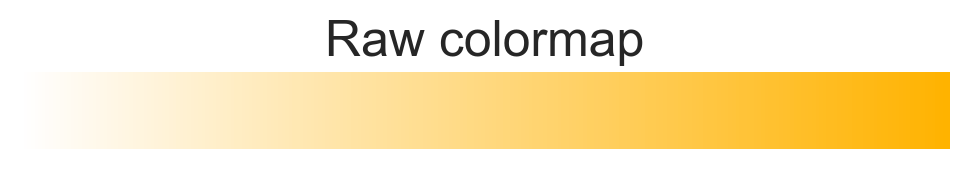

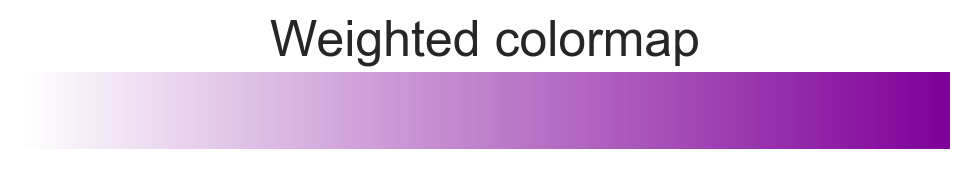

In [2]:
# ── Global visualisation configuration ──────────────────────────────────────

# 1.  General Matplotlib defaults
# ── Global visualisation configuration ──────────────────────────────────────
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update(
    {
        # ── Canvas size & resolution ───────────────────────────────────────────
        # Default figure size: 12×8 inches  →  4800×3200 px when exported at 400 dpi
        "figure.figsize": (12, 8),
        "figure.dpi": 200,  # crisp in-notebook / retina preview
        "savefig.dpi": 400,  # print-quality PNG/PDF
        # ── Fonts ──────────────────────────────────────────────────────────────
        "font.family": "sans-serif",
        "font.sans-serif": ["Roboto", "DejaVu Sans", "Arial"],
        "axes.titlesize": 24,
        # "axes.titleweight": "bold",
        "axes.labelsize": 24,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 20,
        # ── Axis & spine aesthetics ────────────────────────────────────────────
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.linewidth": 1,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.4,
        "grid.alpha": 0.8,
        # ── Colour cycle (colour-blind-safe) ───────────────────────────────────
        "axes.prop_cycle": mpl.cycler(color=sns.color_palette("Set2")),
        # ── Figure background ─────────────────────────────────────────────────
        "figure.facecolor": "white",
    }
)

# Seaborn theme inherits the rcParams above
sns.set_theme(context="talk", style="whitegrid", palette="Set2")


# 2.  Seaborn theme (inherits Matplotlib rcParams)
sns.set_theme(
    context="talk",  # slightly larger fonts for presentations / papers
    style="whitegrid",  # grid only on y-axis (good for histograms)
    palette="Set2",  # matches the rcParams colour cycle
)


# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=True, **savefig_kwargs)


# 4.  Colour constants for this project (optional convenience)
# COL_RAW = "#1f77b4"  # e.g. unweighted sample
COL_RAW = "#ffb300"
# COL_WEIGHTED = "#d62728"  # weighted sample
COL_WEIGHTED = "#7F0099CE"  # weighted sample
COL_REF = "0.25"  # census reference (neutral grey)
COL_CENSUS = "#A5A5A5"

# generate colormaps from white to colour
COL_WHITE = "white"
COL_RAW_RGB = mpl.colors.to_rgb(COL_RAW)
COL_WEIGHTED_RGB = mpl.colors.to_rgb(COL_WEIGHTED)
CMAP_RAW = mpl.colors.LinearSegmentedColormap.from_list("raw", [COL_WHITE, COL_RAW_RGB], N=256)
CMAP_WEIGHTED = mpl.colors.LinearSegmentedColormap.from_list(
    "weighted", [COL_WHITE, COL_WEIGHTED_RGB], N=256
)
# visualize the colormaps
# if __name__ == "__main__":
fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_RAW)
ax.set_title("Raw colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_raw.png")

fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_WEIGHTED)
ax.set_title("Weighted colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_weighted.png")

In [3]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
DATA_DIR = Path("~/Projects/neuroaging/data")

# Output directory for figures
OUTPUT_DIR = Path("/home/galkepler/Projects/neuroaging/figures/fig2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [5]:
metric = "gm_vol"
distribution_metric = "qfmean"
data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(drop=True)

data["age_squared"] = data["age_at_scan"] ** 2
data["sex"] = data["sex"].map({"M": 0, "F": 1})

/tmp/ipykernel_599660/4252506202.py:3: DtypeWarning: Columns (1,7,61,67,71,72,73,74,75,77,78,79,80,85,86,87,88,89,90,92,106,109,114,115,116,117) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(drop=True)


In [6]:
metric_col = "volume" if metric == "gm_vol" else distribution_metric

In [7]:
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

In [8]:
def assign_weights_by_population(
    data: pd.DataFrame,
    population_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    range_start: str = "range_start",
    range_end: str = "range_end",
    total: str = "total",
) -> np.ndarray:
    """
    Post-stratification weights so the age distribution of *data*
    matches an external reference.

    - Accepts integer or float ages.
    - Handles boundary ages (include_lowest=True).
    - Leaves bins with zero sample untouched (weight=0 → later dropped).
    - Returns weights whose mean == 1 across *non-zero* weights.
    """

    # 1. Make sure population bins are well-formed
    pop = (
        population_df[[range_start, range_end, total]]
        .sort_values(range_start)
        .reset_index(drop=True)
    )
    if (pop[range_end] <= pop[range_start]).any():
        raise ValueError("Each range_end must exceed range_start.")
    if (pop[range_start].iloc[1:].values < pop[range_end].iloc[:-1].values).any():
        raise ValueError("Age bins overlap or are not strictly increasing.")

    # 2. Bin edges for pd.cut  →  [..., last_end]  (right-inclusive)
    bin_edges = pop[range_start].tolist() + [pop[range_end].iloc[-1]]

    # Population proportions (works for % or counts)
    pop_prop = pop[total] / pop[total].sum()

    # 3. Assign each participant to a bin
    sample_bins = pd.cut(
        data[age_col],
        bins=bin_edges,
        right=True,  # include right edge
        include_lowest=True,  # include first left edge
        labels=pop.index,  # integer labels 0..n-1
    )

    # 4. Sample distribution
    sample_counts = sample_bins.value_counts(sort=False)
    sample_prop = sample_counts / sample_counts.sum()

    # 5. Weight lookup  (population / sample)  — careful with zeros
    weight_lookup = pop_prop / sample_prop.replace(0, np.nan)

    # 6. Map to rows; bins with zero sample → NaN weight → drop later
    w = sample_bins.map(weight_lookup).to_numpy()

    # Assign *zero* weight (instead of 1) to rows that were NaN
    w = np.where(np.isnan(w), 0.0, w)

    # 7. Rescale so mean(weight > 0) == 1
    positive = w > 0
    w[positive] = w[positive] / w[positive].mean()

    return w

In [9]:
import numpy as np
import pandas as pd


# ─────────────────────────────────────────────────────────────────────────────
def compute_poststrat_weights(
    sample_df: pd.DataFrame,
    pop_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    start_col: str = "range_start",
    end_col: str = "range_end",
    pop_total_col: str = "total",
    cap: float | None = None,
    return_bin_table: bool = False,
):
    """
    Post-stratification weights so that the age distribution of *sample_df*
    matches an external population distribution supplied in *pop_df*.

    Parameters
    ----------
    sample_df : DataFrame with an ``age_col`` column (years; int or float).
    pop_df    : DataFrame with columns
                    [start_col, end_col, pop_total_col].
                * Values in ``pop_total_col`` can be counts **or** percentages
                  (they are internally re-scaled to proportions).
                * The row order doesn’t matter; they will be sorted.
    cap       : Optional float.  If provided, weights are truncated at
                ``cap × mean(weight)`` and then re-scaled so mean(weight)=1.
    return_bin_table : If True, also return a DataFrame summarising
                       n_sample, n_pop, and weight_factor for every bin.

    Returns
    -------
    weights   : 1-D numpy array aligned with ``sample_df.index``.
    bin_table : (optional) tidy per-bin summary (see above).
    """

    # 1 ── tidy & validate the population table --------------------------------
    pop = (
        pop_df[[start_col, end_col, pop_total_col]]
        .dropna()
        .astype({start_col: int, end_col: int, pop_total_col: float})
        .sort_values(start_col)  # your CSV is descending; fix that
        .reset_index(drop=True)
    )

    if (pop[end_col] <= pop[start_col]).any():
        raise ValueError("Each range_end must exceed range_start.")

    if (pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values).any():
        overlap = pop.iloc[
            np.where(pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values)[0] + 1
        ][[start_col, end_col]]
        raise ValueError(
            "Age bins overlap (rows shown below) — "
            "merge / correct them before weighting:\n"
            f"{overlap}"
        )

    # 2 ── build right-inclusive bin edges  (···| s_i  …  e_i | s_{i+1} …) ----
    edges = pop[start_col].tolist() + [pop[end_col].iloc[-1]]

    # 3 ── assign every participant to a bin -----------------------------------
    s_bins = pd.cut(
        sample_df[age_col],
        bins=edges,
        right=True,
        include_lowest=True,
        labels=pop.index,  # categorical labels 0,1,…
    )

    # 4 ── compute *sample* and *population* proportions per bin --------------
    n_sample = s_bins.value_counts(sort=False).sort_index()
    prop_sample = n_sample / n_sample.sum()

    prop_pop = pop[pop_total_col] / pop[pop_total_col].sum()

    # 5 ── weight factor = pop_prop / sample_prop ------------------------------
    weight_factor = prop_pop / prop_sample.replace(0, np.nan)  # avoid /0 → NaN

    # 6 ── map factor back to each row ----------------------------------------
    w = s_bins.map(weight_factor).astype(float).to_numpy()
    w = np.where(np.isnan(w), 0.0, w)  # rows that fell outside bins → 0

    # 7 ── optional weight truncation (winsorisation) --------------------------
    if cap is not None and cap > 0:
        mean_pos = w[w > 0].mean()
        w = np.clip(w, 0, cap * mean_pos)

    # 8 ── re-scale so mean(weight > 0) == 1 -----------------------------------
    positive = w > 0
    w[positive] = w[positive] / w[positive].mean()

    # 9 ── return --------------------------------------------------------------
    if return_bin_table:
        bin_tbl = pd.DataFrame(
            {
                "n_sample": n_sample,
                "n_pop": prop_pop * n_sample.sum(),  # rescaled to sample size
                "prop_sample": prop_sample,
                "prop_pop": prop_pop,
                "weight_factor": weight_factor,
            }
        )
        return w, bin_tbl

    return w

In [10]:
# assign weights
data["weight"], _ = compute_poststrat_weights(
    data,
    israel_population,
    age_col="age_at_scan",
    cap=None,  # try None first; if still spiky, use 4 or 5
    return_bin_table=True,
)

In [11]:
from statsmodels.formula.api import ols, wls
import statsmodels.formula.api as smf


def regional_models(region_data: pd.DataFrame, metric_col: str, model: str, covariates: list):
    """
    Fit a linear model to the data for each region.
    """
    # Fit the model
    if model == "ols":
        model = ols(f"{metric_col} ~ {' + '.join(covariates)}", data=region_data)
    elif model == "wls":
        model = wls(
            f"{metric_col} ~ {' + '.join(covariates)}",
            data=region_data,
            weights=region_data["weight"],
        )
    else:
        raise ValueError("Model must be either 'ols' or 'wls'.")

    # Fit the model
    results = model.fit()

    # Return the results
    return results

In [12]:
# from tqdm import tqdm

# # Set up dataframes to store results
# lin_unw, lin_w, quad_unw, quad_w = parcels.copy(), parcels.copy(), parcels.copy(), parcels.copy()

# covariates = ["age_at_scan", "sex"]
# if metric == "gm_vol":
#     covariates += ["tiv"]

# for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
#     region_data = data[data[region_col] == row[region_col]].copy()
#     region_data.rename(columns={metric_col: "value"}, inplace=True)
#     for results_df, model, is_quadratic in zip(
#         [lin_unw, lin_w, quad_unw, quad_w],
#         ["ols", "wls", "ols", "wls"],
#         [False, False, True, True],
#     ):
#         # Fit the model
#         if is_quadratic:
#             region_data["age_squared"] = region_data["age_at_scan"] ** 2
#             results = regional_models(region_data, "value", model, covariates + ["age_squared"])
#         else:
#             results = regional_models(region_data, "value", model, covariates)

#         # Store the results
#         results_df.loc[i, "model"] = results
#         results_df.loc[i, "pvalue"] = results.f_pvalue
#         results_df.loc[i, "r2"] = results.rsquared
#         results_df.loc[i, "r2_adj"] = results.rsquared_adj
#         results_df.loc[i, "n"] = len(region_data)
#         # if i == 405 and model == "wls" and is_quadratic:
#         #     a = results

In [ ]:
from tqdm import tqdm

# Set up dataframes to store results
quad_w, lin_w = parcels.copy(), parcels.copy()

covariates = ["age_at_scan", "sex"]
if metric == "gm_vol":
    covariates += ["tiv"]

for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
    region_data = data[data[region_col] == row[region_col]].copy()
    region_data.rename(columns={metric_col: "value"}, inplace=True)
    lin_model = smf.wls(
        "value ~ " + " + ".join(covariates),
        data=region_data,
        weights=region_data["weight"],
    ).fit()
    quad_model = smf.wls(
        "value ~ " + " + ".join(covariates) + " + I(age_at_scan ** 2)",
        data=region_data,
        weights=region_data["weight"],
    ).fit()

    for results_df, model, is_quadratic in zip(
        [lin_w, quad_w],
        [lin_model, quad_model],
        [False, True],
    ):
        # Store the results
        results_df.loc[i, "model"] = model
        results_df.loc[i, "pvalue"] = model.f_pvalue
        results_df.loc[i, "r2"] = model.rsquared
        results_df.loc[i, "r2_adj"] = model.rsquared_adj
        results_df.loc[i, "n"] = len(region_data)
        results_df.loc[i, "beta1"] = model.params["age_at_scan"]
        results_df.loc[i, "pvalue_beta1"] = model.pvalues["age_at_scan"]
        if is_quadratic:
            results_df.loc[i, "beta2"] = model.params["I(age_at_scan ** 2)"]
            results_df.loc[i, "pvalue_beta2"] = model.pvalues["I(age_at_scan ** 2)"]
        # if i == 405 and model == "wls" and is_quadratic:
        #     a = results

Fitting models: 100%|██████████| 454/454 [00:08<00:00, 56.47it/s]


In [ ]:
import numpy as np
from scipy.interpolate import UnivariateSpline
from scipy.signal import find_peaks
from pygam import LinearGAM

class SmoothingSplineModel:
    def __init__(self, model: LinearGAM):
        # x: ages, y: measurements (e.g., brain volume)
        # s: smoothing factor (analogous to how the paper optimized smoothing via BIC)
        self.model = model

    def predict(self, x_pred):
        return self.model.predict(x_pred)

    def first_derivative(self, x_pred):
        """
        Compute the first derivative of the spline at given points.

        Parameters
        ----------
        x_pred : array-like
            Points at which to evaluate the first derivative.

        Returns
        -------
        array-like
            The first derivative of the spline at the given points.
        """
        y_prime = np.zeros(len(x_pred))
        gam_predictions = self.predict(x_pred)
        xx = x_pred[:, 0]
        for i in range(1, len(y_prime) - 1):
            y_prime[i] = (gam_predictions[i + 1] - gam_predictions[i - 1]) / (
                xx[i + 1] - xx[i - 1]
            )
        y_prime[0] = (gam_predictions[1] - gam_predictions[0]) / (xx[1] - xx[0])
        last = len(y_prime) - 1
        y_prime[last] = (gam_predictions[last] - gam_predictions[last - 1]) / (
            xx[last] - xx[last - 1]
        )
        return y_prime

    def second_derivative(self, x_pred):
        """
        Compute the second derivative of the spline at given points.

        Parameters
        ----------
        x_pred : array-like
            Points at which to evaluate the second derivative.

        Returns
        -------
        array-like
            The second derivative of the spline at the given points.
        """
        y_double_prime = np.zeros(len(x_pred))
        y_prime = self.first_derivative(x_pred)
        xx = x_pred[:, 0]
        for i in range(1, len(y_double_prime) - 1):
            y_double_prime[i] = (y_prime[i + 1] - y_prime[i - 1]) / (xx[i + 1] - xx[i - 1])
        y_double_prime[0] = y_prime[1] - y_prime[0]
        last = len(y_double_prime) - 1
        y_double_prime[last] = y_prime[last] - y_prime[last - 1]  # backward diff
        return y_double_prime


# def find_critical_ages(spline_model, age_range, height=0.5, tol=1e-5):
#     # Find where the second derivative changes quickly (inflection points)
#     second_derivs = spline_model.second_derivative(age_range)
#     # height should be either the input height or the max of the second derivatives
#     # if height > np.max(np.abs(second_derivs)):
#     #     height = np.max(np.abs(second_derivs)) - tol
#     # Peaks/troughs: maxima/minima in curvature, likely to be 'critical ages'
#     peaks, _ = find_peaks(second_derivs, height=height)
#     troughs, _ = find_peaks(-second_derivs, height=height)
#     critical_indices = np.sort(np.concatenate([peaks, troughs]))
#     critical_ages = age_range[critical_indices]
#     return critical_ages

def find_zero_crossings(x, y):
    """Find x-locations where y changes sign."""
    sign_change = np.where(np.diff(np.sign(y)))[0]
    # Interpolate to get approximate x value for exact zero-crossing
    x_crit = []
    for idx in sign_change:
        x0, x1 = x[idx], x[idx+1]
        y0, y1 = y[idx], y[idx+1]
        # Linear interpolation
        if y1 != y0:
            xc = x0 - y0 * (x1 - x0) / (y1 - y0)
        else:
            xc = x0
        x_crit.append(xc)
    return np.array(x_crit)

def find_critical_ages(spline_model, age_range, height=0.5, tol=1e-5):
    # We calculated the ages where the slope of the local smoothing curve changed (the second derivative),
    # using the expression −d2f(age)/dage2

    second_derivs = spline_model.second_derivative(age_range)
    return find_zero_crossings(age_range[:,0], second_derivs)

In [ ]:
import numpy as np


def group_critical_points(points, tol=1.0):
    if len(points) == 0:
        return points
    points = np.sort(points)
    grouped_points = []
    current_group = [points[0]]
    for p in points[1:]:
        if abs(p - current_group[-1]) <= tol:
            current_group.append(p)
        else:
            grouped_points.append(np.mean(current_group))
            current_group = [p]
    grouped_points.append(np.mean(current_group))
    return np.array(grouped_points)

In [46]:
from pygam import LinearGAM, s
from scipy.stats import pearsonr
# Set up dataframes to store results
gam_w = parcels.copy()

covariates = ["age_at_scan", "sex"]
if metric == "gm_vol":
    covariates += ["tiv"]

grid_df = pd.DataFrame(
    {
        "age_at_scan": np.linspace(data["age_at_scan"].min(), data["age_at_scan"].max(), 500),
        "sex": data["sex"].mode()[0],  # use the most common
        # "tiv": np.random.choice(data["tiv"].unique(), 100)
    }
)
if metric == "gm_vol":
    grid_df["tiv"] = data["tiv"].mean()  # use the mean TIV

floating_round = 6 if "vol" not in metric else 0
tol = 10
lams = np.logspace(1, 3, 11)

for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
    region_data = data[data[region_col] == row[region_col]].copy()
    region_data.rename(columns={metric_col: "value"}, inplace=True)
    x_gam = region_data[covariates].values
    y_gam = region_data["value"].values
    gam = LinearGAM(s(0, n_splines=5))
    gam.gridsearch(x_gam, y_gam, weights=region_data["weight"].values, lam=lams, progress=False)
    
    # keep
    # Store the results
    gam_w.loc[i, "model"] = gam
    r,p = pearsonr(gam.predict(x_gam), y_gam)
    gam_w.loc[i, "pvalue"] = p
    gam_w.loc[i, "pearson_r"] = r
    r2 = gam.statistics_["pseudo_r2"]
    gam_w.loc[i, "explained_deviance"] = r2["explained_deviance"]
    gam_w.loc[i, "McFadden"] = r2["McFadden"]
    gam_w.loc[i, "McFadden_adj"] = r2["McFadden_adj"]
    
    # break

Fitting models:   0%|          | 0/454 [00:00<?, ?it/s]

Fitting models: 100%|██████████| 454/454 [00:30<00:00, 15.01it/s]


In [47]:
def calc_bic(model, x, y):
    """
    Calculate BIC for a given model.
    """
    if isinstance(model, LinearGAM):
        # For GAM, we use the effective degrees of freedom
        k = model.statistics_['edof']
    else:
        # For other models, we can use the number of parameters
        k = model.df_model
    n = len(y)
    rss = np.sum((y - model.predict(x)) ** 2)
    bic = n * np.log(rss / n) + k * np.log(n)
    return bic



w_compare = parcels.copy()
for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Calculating BIC"):
    region_data = data[data[region_col] == row[region_col]].copy()
    region_data.rename(columns={metric_col: "value"}, inplace=True)
    x_gam = region_data[covariates].values
    y_gam = region_data["value"].values
    m = gam_w.loc[i, "model"]
    l = lin_w.loc[i, "model"]
    q = quad_w.loc[i, "model"]
    
    # Calculate BIC for each model
    w_compare.loc[i, "BIC_gam"] = calc_bic(m, x_gam, y_gam)
    w_compare.loc[i, "BIC_lin"] = calc_bic(l, region_data, y_gam)
    w_compare.loc[i, "BIC_quad"] = calc_bic(q, region_data, y_gam)


Calculating BIC: 100%|██████████| 454/454 [00:06<00:00, 69.66it/s]


In [48]:
w_compare["BIC_diff_gam_lin"] = w_compare["BIC_gam"] - w_compare["BIC_lin"]
w_compare["BIC_diff_gam_quad"] = w_compare["BIC_gam"] - w_compare["BIC_quad"]
w_compare["BIC_diff_quad_lin"] = w_compare["BIC_quad"] - w_compare["BIC_lin"]


In [49]:
def is_peak(derivative, index, peak_type="top", window=10):
    """
    Check if the point at `index` is a peak (top or bottom) in the derivative.

    Parameters:
        derivative: array-like, the first derivative vector.
        index: int, the index to check.
        peak_type: str, either "top" (maximum) or "bottom" (minimum).
        window: int, number of points to look both sides of index for sign change.

    Returns:
        True if point is a peak of specified type, else False.
    """
    # Check boundaries
    if index - window < 0:
        window = index  # adjust window to avoid negative index
    if index + window >= len(derivative):
        window = len(derivative) - index - 1

    # Get left and right windows
    left = derivative[index - window:index]
    right = derivative[index+1:index+1+window]
    # print(left, right, this_value)
    # For maxima ("top"): want sign change + to -
    if peak_type == "top":
        # Find if any point to the left is positive, and any right is negative
        left_positive = np.nanmean(left) > 0
        right_negative = np.nanmean(right) < 0
        # Peak if derivative at index is near zero, left>0, right<0
        return left_positive and right_negative

    # For minima ("bottom"): want sign change - to +
    elif peak_type == "bottom":
        left_negative = np.nanmean(left) < 0
        right_positive = np.nanmean(right) > 0
        return left_negative and right_positive

    else:
        raise ValueError('peak_type must be "top" or "bottom"')

def investigate_apsi(model: SmoothingSplineModel, age_range: np.ndarray, floating_round: int, peak_type: str = "top"):
    """
    investigate whether the age should be considered a critical age
    An APSI age is where derivative is zero and it's a peak (either top or bottom)
    """
    first_derivatives = model.first_derivative(age_range)
    apsi_ages = np.round(first_derivatives, floating_round) == 0
    # an apsi should be an actual "curvature" inflection point (an not in a middle of a plateau)
    # so we check if the second derivative is positive (concave up) or negative (concave down)
    # at the point where the first derivative is zero
    # if the second derivative is positive, it is a critical age
    result = []
    for i, is_apsi in enumerate(apsi_ages):
        if is_apsi and is_peak(first_derivatives, i, peak_type):
            result.append(i)
    return result

In [50]:
cols_to_delete = gam_w.filter(regex="stab_age|crit_age").columns
gam_w[cols_to_delete] = np.nan  # initialize with NaN

apsi_func = np.argmax if "vol" in metric else np.argmin

crit_height = 1 if "vol" in metric else 1e-10

for i, row in gam_w.iterrows():
    gam = row["model"]
    gam_model = SmoothingSplineModel(gam)
    first_derivative = gam_model.first_derivative(grid_df.values)
    predictions = gam_model.predict(grid_df.values)
    # apsi age
    apsi_age = apsi_func(predictions)
    apsi_age = grid_df.loc[apsi_age, "age_at_scan"]
    # apsi_ages = investigate_apsi(gam_model, grid_df.values, floating_round=floating_round, peak_type="top")
    # # apsi_ages = np.round(first_derivative, floating_round) == 0
    # apsi_ages = grid_df.loc[apsi_ages, "age_at_scan"]
    # apsi_ages = group_critical_points(apsi_ages, tol=tol)
    # if len(apsi_ages) > 0:
    #     break
    critical_ages = find_critical_ages(gam_model, grid_df.values, height=crit_height)
    # critical_ages = [crit[0] for crit in critical_ages]  # take the first element of each tuple
    critical_ages = group_critical_points(critical_ages, tol=tol)
    # for j, apsi_age in enumerate(apsi_ages):
    gam_w.loc[i, "stab_age"] = apsi_age
    for j, critical_age in enumerate(critical_ages):
        gam_w.loc[i, f"crit_age_{j}"] = critical_age

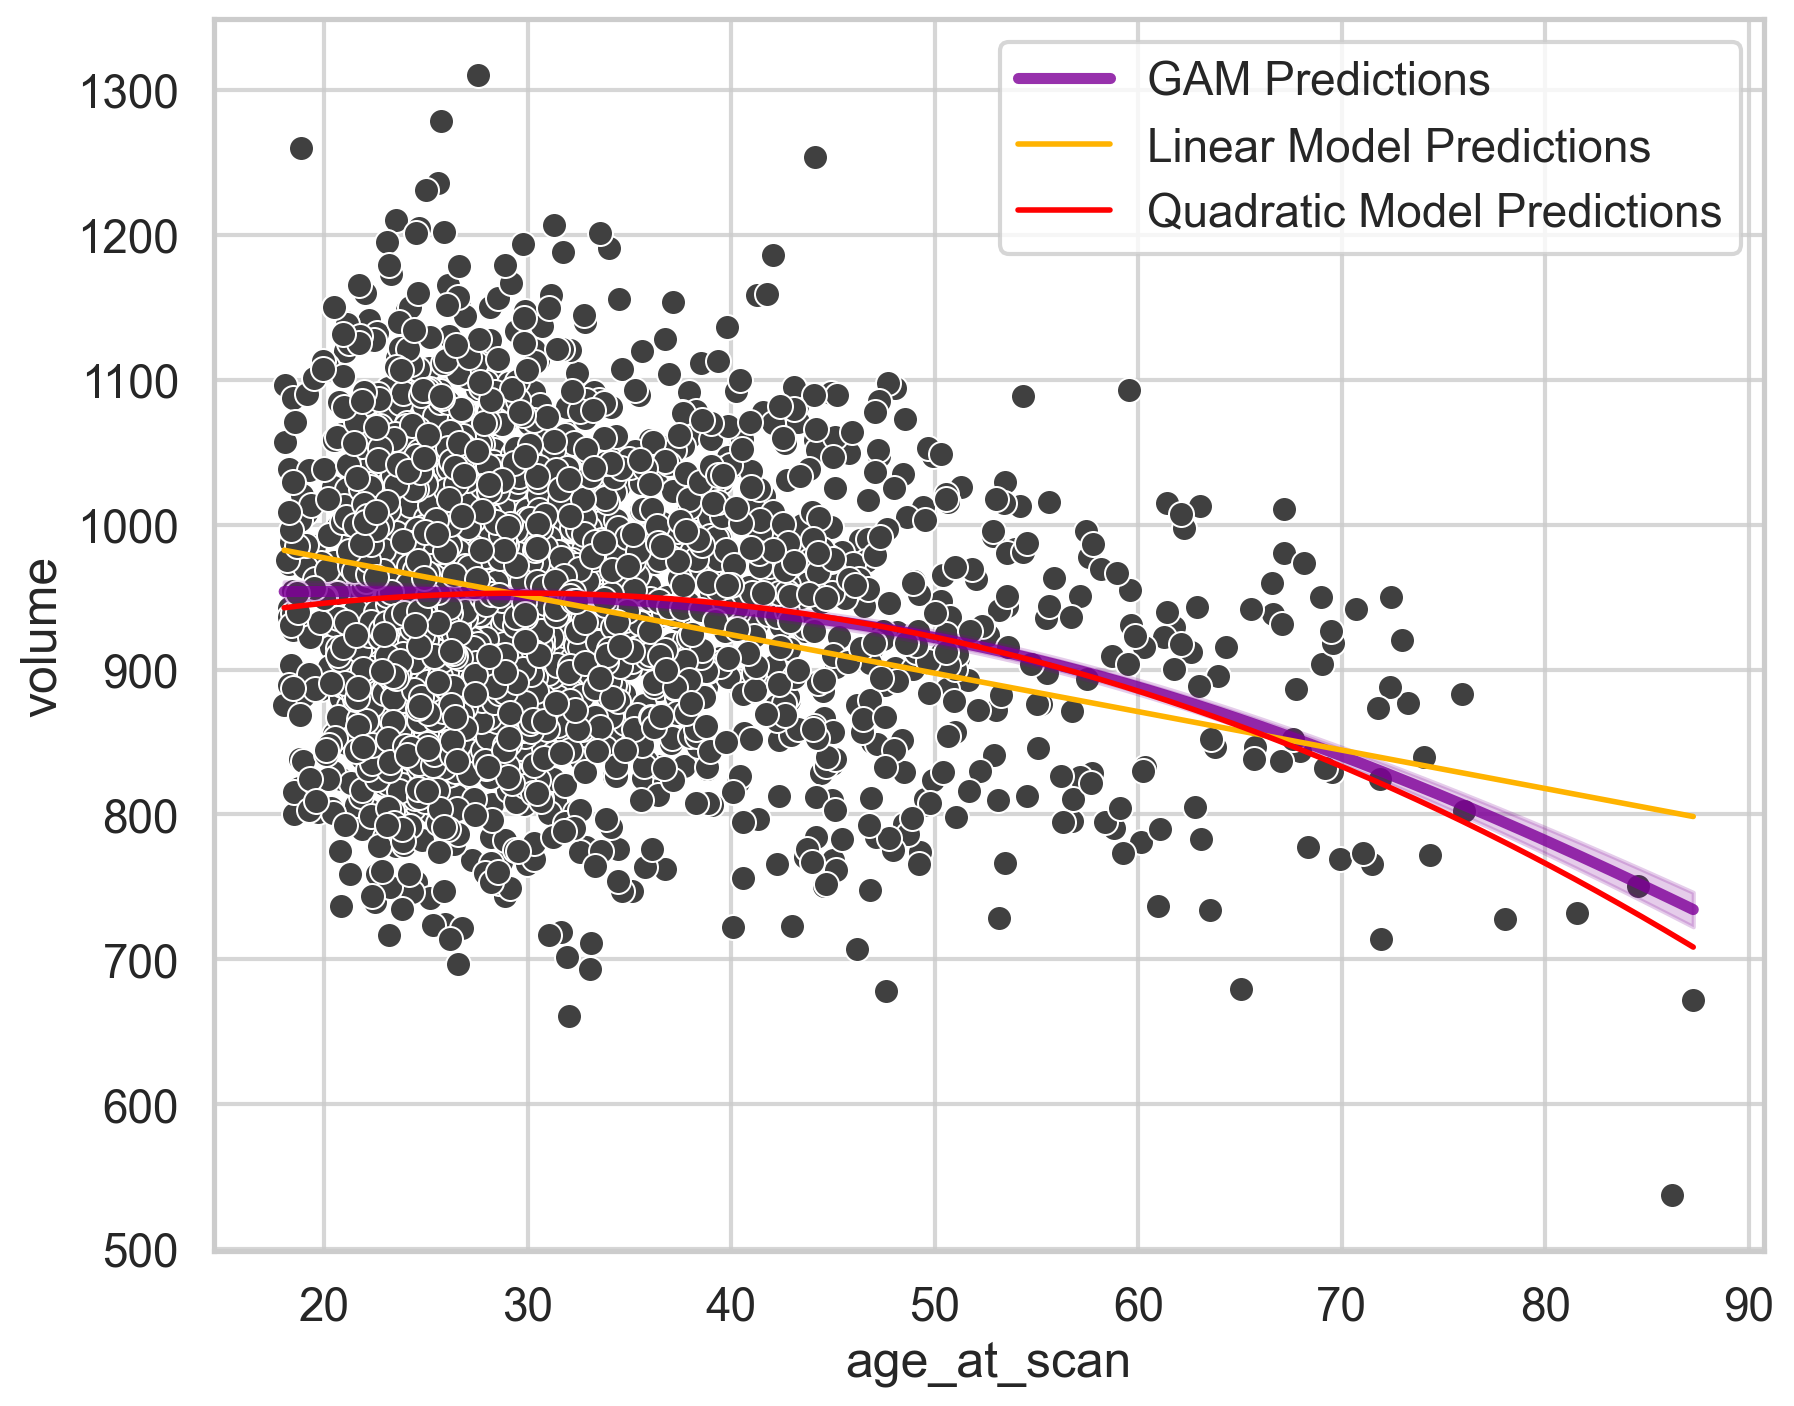

In [57]:
n_samples = 500
grid_df = pd.DataFrame({
    "age_at_scan": np.linspace(data["age_at_scan"].min(), data["age_at_scan"].max(), n_samples),
    "sex": data["sex"].mode()[0],  # use the most common
})
if "vol" in metric:
    grid_df["tiv"] = data["tiv"].mean()  # use the mean TIV

# best_i = gam_w.loc[gam_w["crit_age_0"]<70].sort_values("explained_deviance", ascending=False).index[0]
best_i = w_compare["BIC_diff_quad_lin"].idxmin()
# best_i = 5
y_true = data[data[region_col] == parcels.loc[best_i, region_col]]
region_data = data[data[region_col] == parcels.loc[best_i, region_col]].copy()
region_data.rename(columns={metric_col: "value"}, inplace=True)

gam = gam_w.loc[best_i, "model"]
quad_model = quad_w.loc[best_i, "model"]
lin_model = lin_w.loc[best_i, "model"]

gam_predictions = gam.predict(grid_df[covariates].values)
gm_ci = gam.confidence_intervals(grid_df[covariates].values)

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(
    x="age_at_scan",
    y=metric_col,
    data=y_true,
    color=COL_REF
)

# Plot the predictions
# plt.scatter(data["age_at_scan"], data[metric_col], alpha=0.1, color="grey")
ax.plot(grid_df["age_at_scan"], gam_predictions, label="GAM Predictions", color=COL_WEIGHTED, linewidth=4)
# Plot the linear model predictions
# lin_predictions = lin_model.predict(grid_df[covariates])
# ax.plot(grid_df["age_at_scan"], lin_predictions, label="Linear Model Predictions", color=COL_RAW, linewidth=2)
# # Plot the quadratic model predictions
# quad_predictions = quad_model.predict(grid_df[covariates])
# ax.plot(grid_df["age_at_scan"], quad_predictions, label="Quadratic Model Predictions", color=COL_RAW, linewidth=2)
# add confidence intervals
ax.fill_between(
    grid_df["age_at_scan"],
    gm_ci[:, 0],
    gm_ci[:, 1],
    color=COL_WEIGHTED,
    alpha=0.2,
    
    # label="95% CI",
)

# plot linear and quadratic models
lin_predictions = lin_model.predict(grid_df)
ax.plot(
    grid_df["age_at_scan"],
    lin_predictions,
    label="Linear Model Predictions",
    color=COL_RAW,
    linewidth=2,
)
quad_predictions = quad_model.predict(grid_df)
ax.plot(
    grid_df["age_at_scan"],
    quad_predictions,
    label="Quadratic Model Predictions",
    color="red",
    linewidth=2,
)


ax.legend()
# stab_age = gam_w.loc[best_i, "stab_age"]
# ax.axvline(stab_age, linestyle="--", color="red", alpha=0.7, label="Stability Age")

critical_ages = gam_w.filter(regex="crit_age").loc[best_i].dropna()
n_critical_ages = len(critical_ages)
for critical_age in critical_ages:
    ax.axvline(critical_age, linestyle="--", color=COL_RAW, alpha=0.5, label="Critical Age")

if n_critical_ages > 1:
    # remove duplicate labels
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())
else:
    ax.legend()

In [55]:
w_compare.loc[w_compare["BIC_diff_gam_lin"] < -5]

,index,name,base_name,Label Name,network,component,hemisphere,BIC_gam,BIC_lin,BIC_quad,BIC_diff_gam_lin,BIC_diff_gam_quad,BIC_diff_quad_lin
426,427,aGP-rh,aGP,"Pallidum, anterior part",subcortex,Pallidum,R,19272.329694,19278.644687,19218.617407,-6.314993,53.712287,-60.02728


In [145]:
gam.coef_

array([ 347.42781968,  266.27892705,  193.99673895,  154.03327565,
        112.3791861 ,   65.53614443,   84.84424647,   41.31471897,
       -141.82514195, -335.59366702,  788.39268415])

In [127]:
gam.partial_dependence(0, X=grid_df[covariates].values, width=.95)[1]

array([[ 2.55498485e+02,  2.80014937e+02],
       [ 2.54595652e+02,  2.78767196e+02],
       [ 2.53688547e+02,  2.77527348e+02],
       [ 2.52777103e+02,  2.76295586e+02],
       [ 2.51861263e+02,  2.75072099e+02],
       [ 2.50940973e+02,  2.73857069e+02],
       [ 2.50016189e+02,  2.72650671e+02],
       [ 2.49086872e+02,  2.71453071e+02],
       [ 2.48152997e+02,  2.70264426e+02],
       [ 2.47214547e+02,  2.69084882e+02],
       [ 2.46271516e+02,  2.67914572e+02],
       [ 2.45323915e+02,  2.66753619e+02],
       [ 2.44371764e+02,  2.65602129e+02],
       [ 2.43415101e+02,  2.64460194e+02],
       [ 2.42453979e+02,  2.63327891e+02],
       [ 2.41488468e+02,  2.62205280e+02],
       [ 2.40518654e+02,  2.61092404e+02],
       [ 2.39544641e+02,  2.59989288e+02],
       [ 2.38566551e+02,  2.58895940e+02],
       [ 2.37584523e+02,  2.57812350e+02],
       [ 2.36598716e+02,  2.56738489e+02],
       [ 2.35609304e+02,  2.55674312e+02],
       [ 2.34616479e+02,  2.54619757e+02],
       [ 2.

In [263]:
stab_ages

stab_age_0    18.020000
stab_age_1    33.493697
stab_age_2    51.257224
stab_age_3    72.073858
Name: 50, dtype: float64

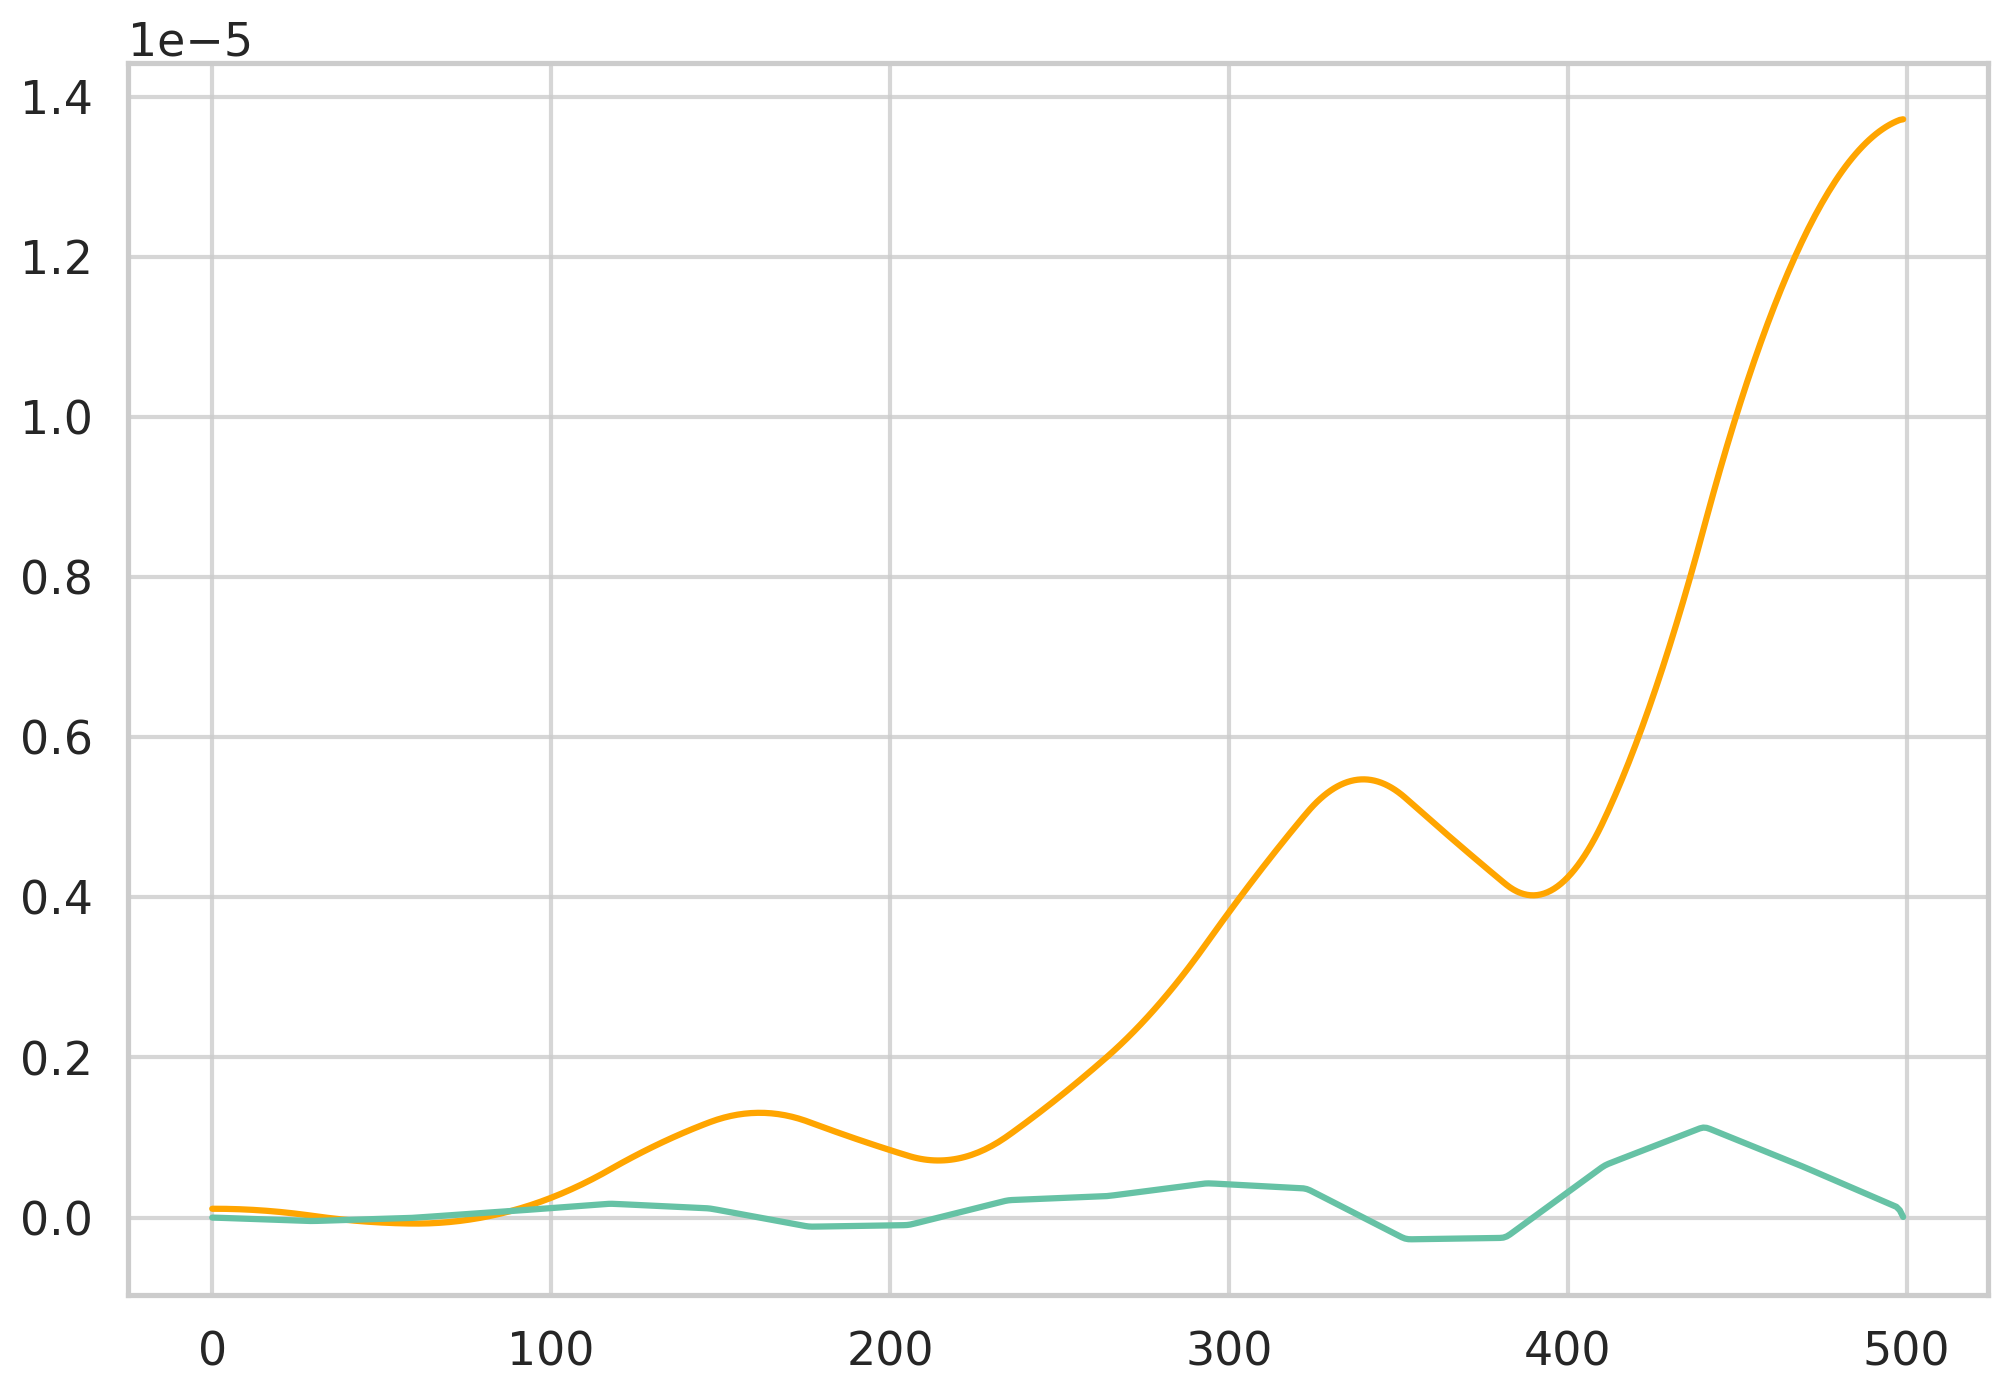

In [230]:
first_derivative = model.first_derivative(grid_df.values)
second_derivative = model.second_derivative(grid_df.values)
plt.plot(first_derivative, label="First Derivative", color="orange")
plt.plot(second_derivative, label="Second")
# peaks

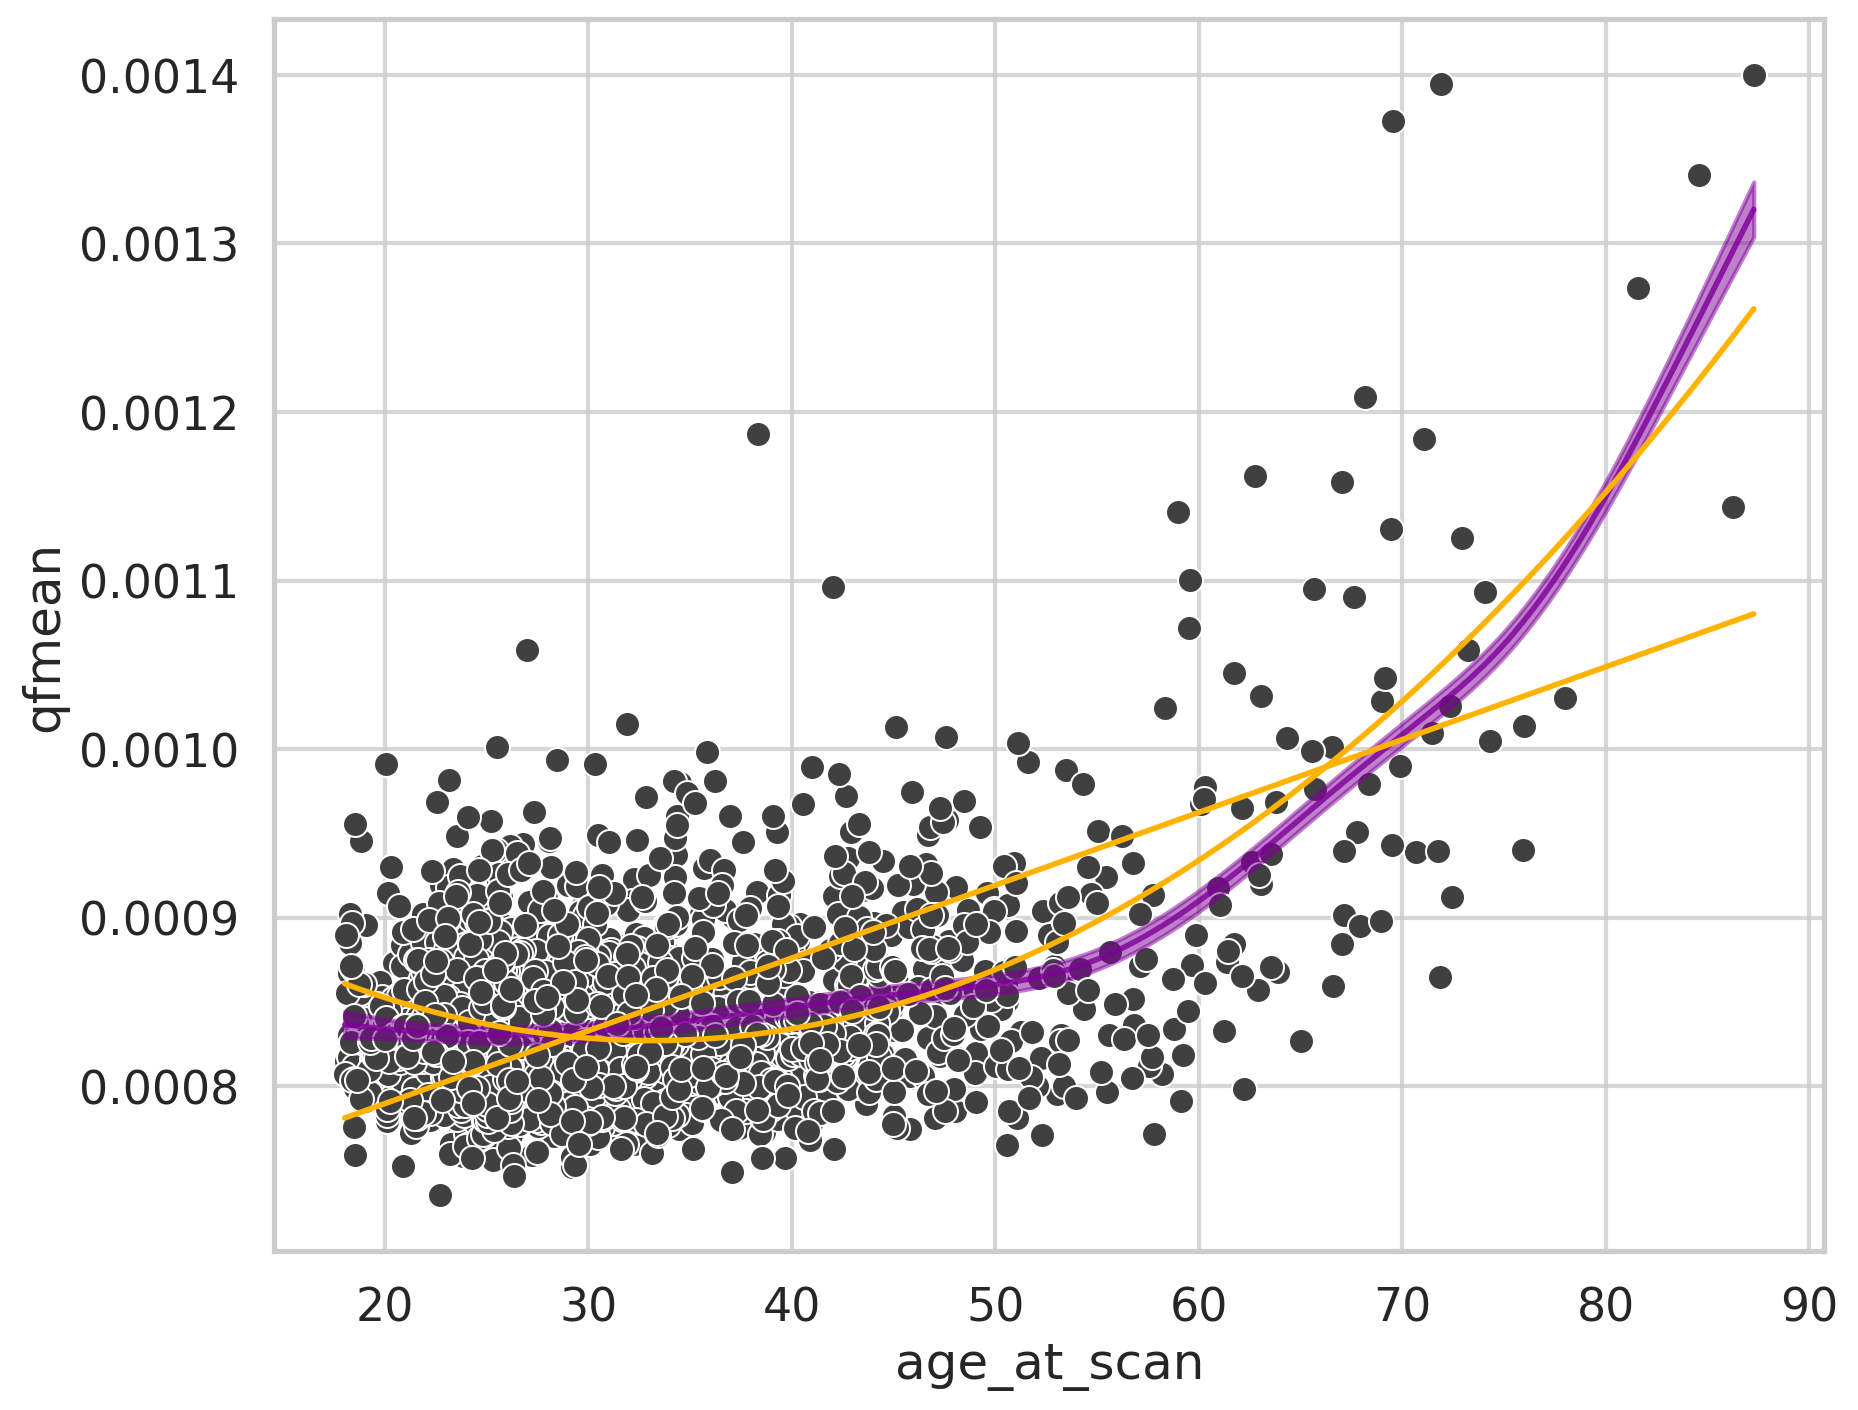

In [223]:
# Plot the critical ages
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(x="age_at_scan", y=metric_col, data=y_true, color=COL_REF)
# Plot the predictions
ax.plot(
    grid_df["age_at_scan"],
    gam_predictions,
    label="GAM Predictions",
    color=COL_WEIGHTED,
    linewidth=2,
)
# Plot the linear model predictions
lin_predictions = lin_model.predict(grid_df[covariates])
ax.plot(
    grid_df["age_at_scan"],
    lin_predictions,
    label="Linear Model Predictions",
    color=COL_RAW,
    linewidth=2,
    
)
# Plot the quadratic model predictions
quad_predictions = quad_model.predict(grid_df[covariates])
ax.plot(
    grid_df["age_at_scan"],
    quad_predictions,
    label="Quadratic Model Predictions",
    color=COL_RAW,
    linewidth=2,
)
# add confidence intervals
ax.fill_between(
    grid_df["age_at_scan"],
    gm_ci[:, 0],
    gm_ci[:, 1],
    color=COL_WEIGHTED,
    alpha=0.5,
    label="95% CI",
)
# Plot the critical ages
# for age in critical_ages:
#     ax.axvline(
#         age,
#         color="red",
#         linestyle="--",
#         alpha=0.5,
#         label="Critical Age" if age == critical_ages[0] else "",
    # )

In [157]:
XX = grid_df["age_at_scan"].copy().values
Yprime = np.zeros(len(grid_df))
GAMY = gam.predict(grid_df)
for i in range(1, len(Yprime) - 1):
    Yprime[i] = (GAMY[i + 1] - GAMY[i - 1]) / (XX[i + 1] - XX[i - 1])
Yprime[0] = (GAMY[1] - GAMY[0]) / (XX[1] - XX[0])  # forward difference
last = len(Yprime) - 1
Yprime[last] = (GAMY[last] - GAMY[last - 1]) / (XX[last] - XX[last - 1])  # backward diff


second_derivative = np.zeros(len(grid_df))
for i in range(1, len(second_derivative) - 1):
    second_derivative[i] = (Yprime[i + 1] - Yprime[i - 1]) / (XX[i + 1] - XX[i - 1])
second_derivative[0] = (Yprime[1] - Yprime[0])
last = len(second_derivative) - 1
second_derivative[last] = (Yprime[last] - Yprime[last - 1])

Text(0.5, 0, 'Age at Scan')

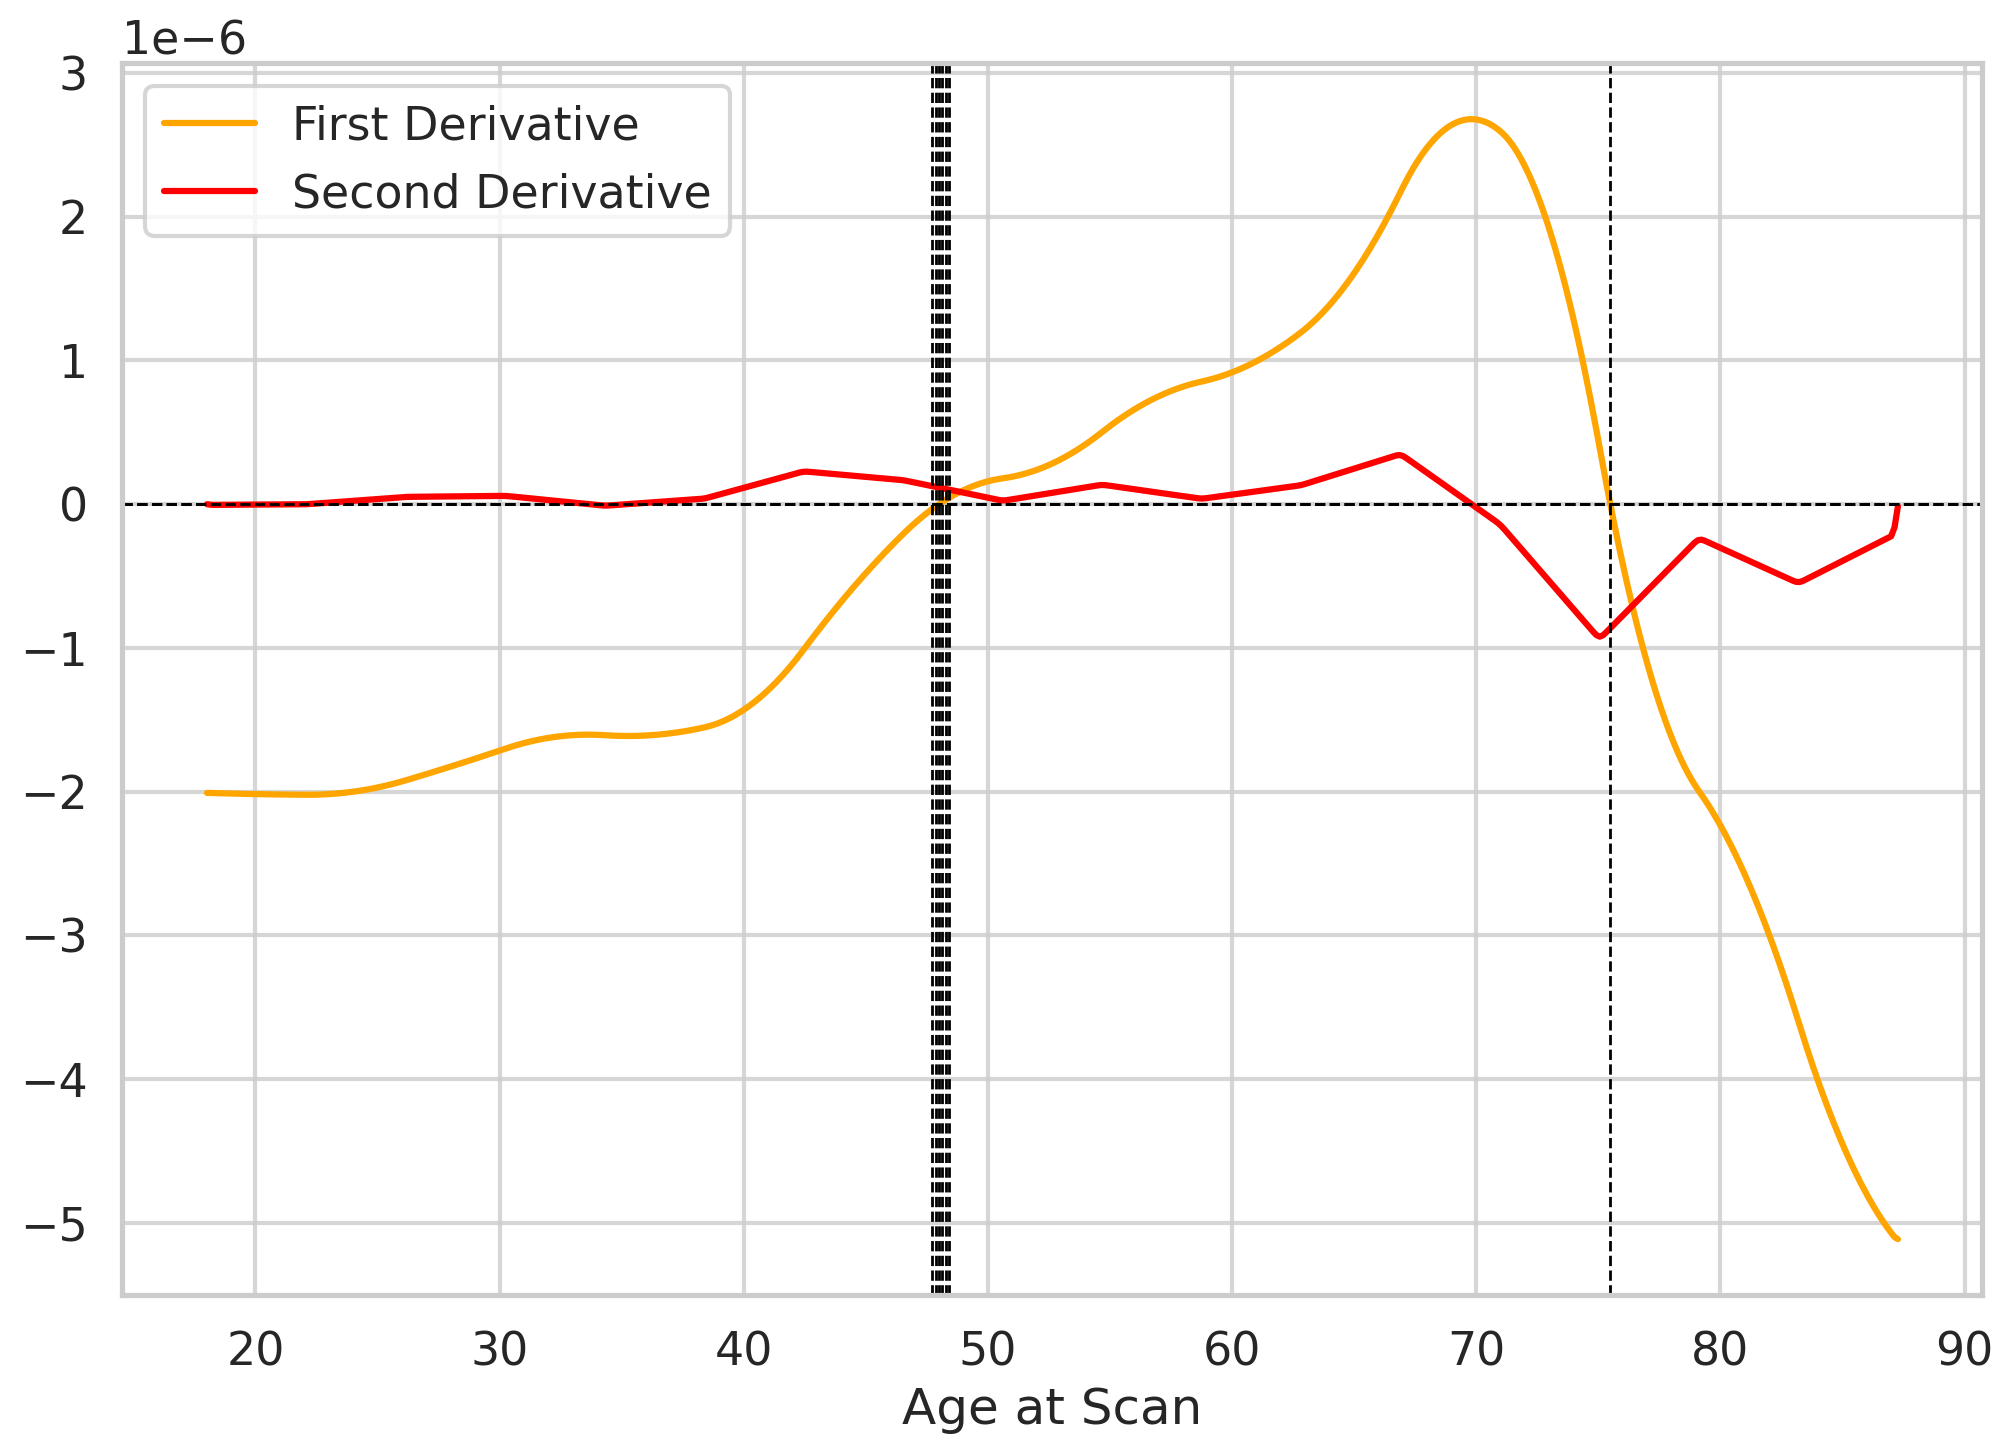

In [169]:
plt.plot(grid_df["age_at_scan"], Yprime, label="First Derivative", color="orange")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.plot(grid_df["age_at_scan"], second_derivative, label="Second Derivative", color="red")
plt.axhline(0, color="black", linestyle="--", linewidth=1)

# add vertical line at first and second derivative zero crossings
Yprime_rounded = np.round(Yprime, 7)  # round to avoid floating point issues
Yprime_indices = np.where(Yprime_rounded == 0)[0]
for i in range(len(Yprime_indices)):
    plt.axvline(grid_df["age_at_scan"].iloc[Yprime_indices[i]], color="black", linestyle="--", linewidth=1)
plt.legend()
plt.xlabel("Age at Scan")

In [ ]:
# np.min(Yprime)

array([-5.11422198e-06])

np.int64(499)

In [ ]:
def find_apsi_and_features_pygam(gam_model, grid_df:pd.DataFrame):
    ages = grid_df.copy()  # pygam expects 2D input
    preds = gam_model.predict(ages)

    # First and second derivatives using partial_dependence
    first_deriv = gam_model.partial_dependence(ages, term=0, derivative=1)
    second_deriv = gam_model.partial_dependence(ages, term=0, derivative=2)

    # APSI: age at minimum predicted value
    apsi_index = np.argmin(preds)
    apsi_age = grid_df["age_at_scan"].iloc[apsi_index]
    apsi_value = preds[apsi_index]

    features = {
        "apsi_age": apsi_age,
        "apsi_value": apsi_value,
        "mean_slope_early": (
            np.mean(first_deriv[age_range < apsi_age]) if np.any(age_range < apsi_age) else np.nan
        ),
        "mean_slope_late": (
            np.mean(first_deriv[age_range > apsi_age]) if np.any(age_range > apsi_age) else np.nan
        ),
        "max_acceleration": np.max(second_deriv),
        "min_acceleration": np.min(second_deriv),
        "mean_volume": np.mean(preds),
        "volume_range": np.ptp(preds),
    }

    return apsi_age, features

apsi_age, features = find_apsi_and_features_pygam(gam, grid_df=grid_df)

TypeError: GAM.partial_dependence() got an unexpected keyword argument 'feature'

In [50]:
gam.partial_dependence?

Signature:
gam.partial_dependence(
    term,
    X=None,
    width=None,
    quantiles=None,
    meshgrid=False,
)
Docstring:
Computes the term functions for the GAM
and possibly their confidence intervals.

if both width=None and quantiles=None,
then no confidence intervals are computed

Parameters
----------
term : int, optional
    Term for which to compute the partial dependence functions.

X : array-like with input data, optional

    if `meshgrid=False`, then `X` should be an array-like
    of shape (n_samples, m_features).

    if `meshgrid=True`, then `X` should be a tuple containing
    an array for each feature in the term.

    if None, an equally spaced grid of points is generated.

width : float on (0, 1), optional
    Width of the confidence interval.

quantiles : array-like of floats on (0, 1), optional
    instead of specifying the prediction width, one can specify the
    quantiles. so width=.95 is equivalent to quantiles=[.025, .975].
    if None, defaults to width.



In [47]:
# find indices where the derivative is zero

# calculate derivative at each point (age)
deriv1 = gam.gradient

AttributeError: 'LinearGAM' object has no attribute 'gradient'

In [45]:
from statsmodels.stats.anova import anova_lm

w_compare = parcels.copy()

# do f test to compare between quadratic and linear models
for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
    # collect models
    model1 = lin_w.loc[i, "model"]
    model2 = quad_w.loc[i, "model"]
    f, p, _ = model2.compare_f_test(model1)
    w_compare.loc[i, "f"] = f
    w_compare.loc[i, "pvalue"] = p
    w_compare.loc[i, "n"] = model1.nobs
    w_compare.loc[i, "AIC(lin)"] = model1.aic
    w_compare.loc[i, "AIC(quad)"] = model2.aic
    w_compare.loc[i, "delta_AIC"] = model2.aic - model1.aic
    w_compare["log(f)"] = np.log(w_compare["f"])
    # do f test to compare between quadratic and linear models
    # model1 = lin_unw.loc[i, "model"]
    # model2 = quad_unw.loc[i, "model"]
    # f, p, _ = model2.compare_f_test(model1)
    # unw_compare.loc[i, "f"] = f
    # unw_compare.loc[i, "pvalue"] = p
    # unw_compare.loc[i, "n"] = model1.nobs
    # weighted

Fitting models: 100%|██████████| 454/454 [00:00<00:00, 1134.40it/s]


In [46]:
# correct everything for multiple comparisons
from statsmodels.stats.multitest import multipletests

for results_df, save_name in zip(
    [lin_w, quad_w, w_compare],
    ["lin_w", "quad_w", "w_compare"],
):
    results_df["p_corrected"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]
    if "pvalue_beta1" in results_df.columns:
        results_df["p_corrected_beta1"] = multipletests(
            results_df["pvalue_beta1"], method="fdr_bh"
        )[1]
    if "pvalue_beta2" in results_df.columns:
        results_df["p_corrected_beta2"] = multipletests(
            results_df["pvalue_beta2"], method="fdr_bh"
        )[1]
    results_df.to_pickle(OUTPUT_DIR / f"{save_name}_{metric}.pkl")

In [47]:
# w_compare.sort_values("p_corrected").head(20)
(w_compare["p_corrected"] < 0.05).sum()
# (w_compare.loc[w_compare["p_corrected"] < 0.05,"delta_AIC"] < -50).sum()
# w_compare.loc[(w_compare["p_corrected"] < 0.05) & (w_compare["delta_AIC"] < -50)].sort_values(
#     "delta_AIC", ascending=True
# )

np.int64(415)

/tmp/ipykernel_2447608/1459870668.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


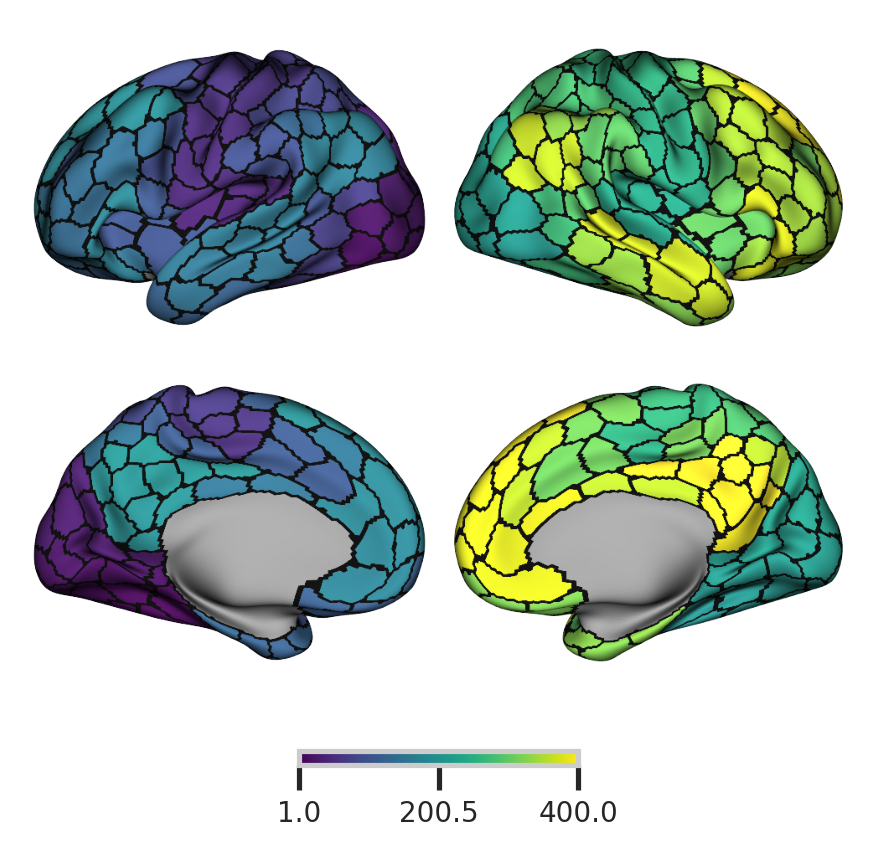

In [48]:
from neuromaps.datasets import fetch_fslr
from surfplot import Plot
from brainspace.datasets import load_parcellation

surfaces = fetch_fslr()
lh, rh = surfaces["inflated"]
p = Plot(lh, rh)

# add schaefer parcellation (no color bar needed)
lh_parc, rh_parc = load_parcellation("schaefer")
p.add_layer({"left": lh_parc, "right": rh_parc}, cbar=True)

p.add_layer({"left": lh_parc, "right": rh_parc}, cmap="gray", as_outline=True, cbar=False)
fig = p.build()
fig.show()

In [49]:
import numpy as np
import pandas as pd
import nibabel as nb
from nilearn import surface, datasets
from surfplot import Plot
from matplotlib.colors import TwoSlopeNorm  # nice diverging colours
from neuromaps.datasets import fetch_fslr
from brainspace.datasets import load_parcellation


atlas_img = nib.load(nifti_matlab)

# ---------------------------------------------------------------------
# 2.  FETCH A STANDARD SURFACE  (fsaverage5 = 10k vertices per hemi)
# ---------------------------------------------------------------------
surfaces = fetch_fslr()
lh, rh = surfaces["inflated"]


# ---------------------------------------------------------------------
# 3.  SAMPLE ATLAS VOXELS → SURFACE  (nearest-neighbour so labels stay int)
# ---------------------------------------------------------------------
# add schaefer parcellation (no color bar needed)
lh_parc, rh_parc = load_parcellation("schaefer")

In [57]:
# ---------------------------------------------------------------------
# 4.  MAP REGION IDs → METRIC VALUES
#     vertices with label 0 (background) → NaN so they render transparent
# ---------------------------------------------------------------------
p_threshold = 0.05
value_threshold = 0

value_map = {}
value_map_subcortex = {"region": [], "value": [], "Hemisphere": []}

# vis_df = w_compare
# value_column = "log(f)"
vis_df = quad_w
value_column = "r2_adj"
# value_column = "beta2"
p_column = "p_corrected"

value_map_lh = {}  # New: separate map for left hemisphere
value_map_rh = {}  # New: separate map for right hemisphere

for i, row in vis_df.iterrows():
    label = row[region_col]
    hemi_row = row["hemisphere"]  # Get hemisphere from your DataFrame row

    # Apply thresholds
    if (row[p_column] < p_threshold) and (np.abs(row[value_column]) > value_threshold):
        value = row[value_column]
    else:
        value = np.nan  # Set to NaN if not significant or below value_threshold
    if value_column == "log(f)":
        if vis_df.loc[i, "delta_AIC"] > -15:
            value = np.nan

    # Populate the correct hemisphere's value_map
    # Assuming your labels are global and you use the 'hemisphere' column to distinguish
    # If your Schaefer labels are already separated by hemi (e.g., 1-200 for LH, 201-400 for RH)
    # then you might only need to check the label range and not the 'hemisphere' column.
    # For Schaefer, the labels usually run 1-N for LH and N+1 - 2N for RH
    if "schaefer" in ATLAS:
        if label > int(ATLAS.split("_")[1]):
            value_map_subcortex["region"].append(label)
            value_map_subcortex["value"].append(value)
            value_map_subcortex["Hemisphere"].append(row["hemisphere"])
        else:
            if hemi_row == "L":
                value_map_lh[label] = value
            elif hemi_row == "R":
                value_map_rh[label] = value
        # Subcortex handling would go here if you were preparing for separate subcortical visualization
        # else: # This implies it's subcortical or other non-surface region
        #     value_map_subcortex["region"].append(label)
        #     value_map_subcortex["value"].append(value)
        #     value_map_subcortex["Hemisphere"].append(row["hemisphere"])

# Vectorize mapping for left and right hemispheres separately
vec_lh = np.vectorize(lambda x: value_map_lh.get(x, np.nan))
data_lh_mapped = vec_lh(lh_parc)  # Apply LH map to LH parcellation
vec_rh = np.vectorize(lambda x: value_map_rh.get(x, np.nan))
data_rh_mapped = vec_rh(rh_parc)  # Apply RH map to RH parcellation

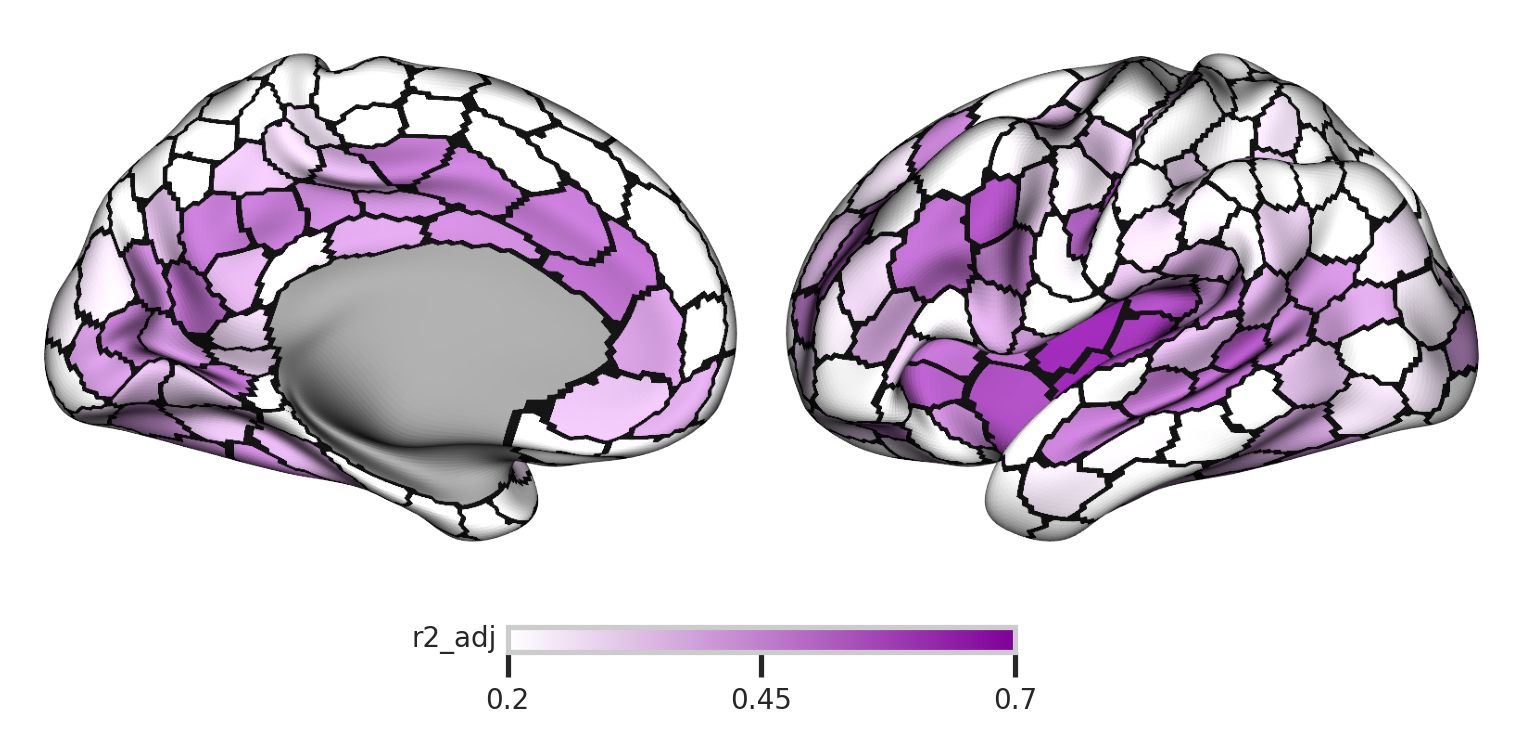

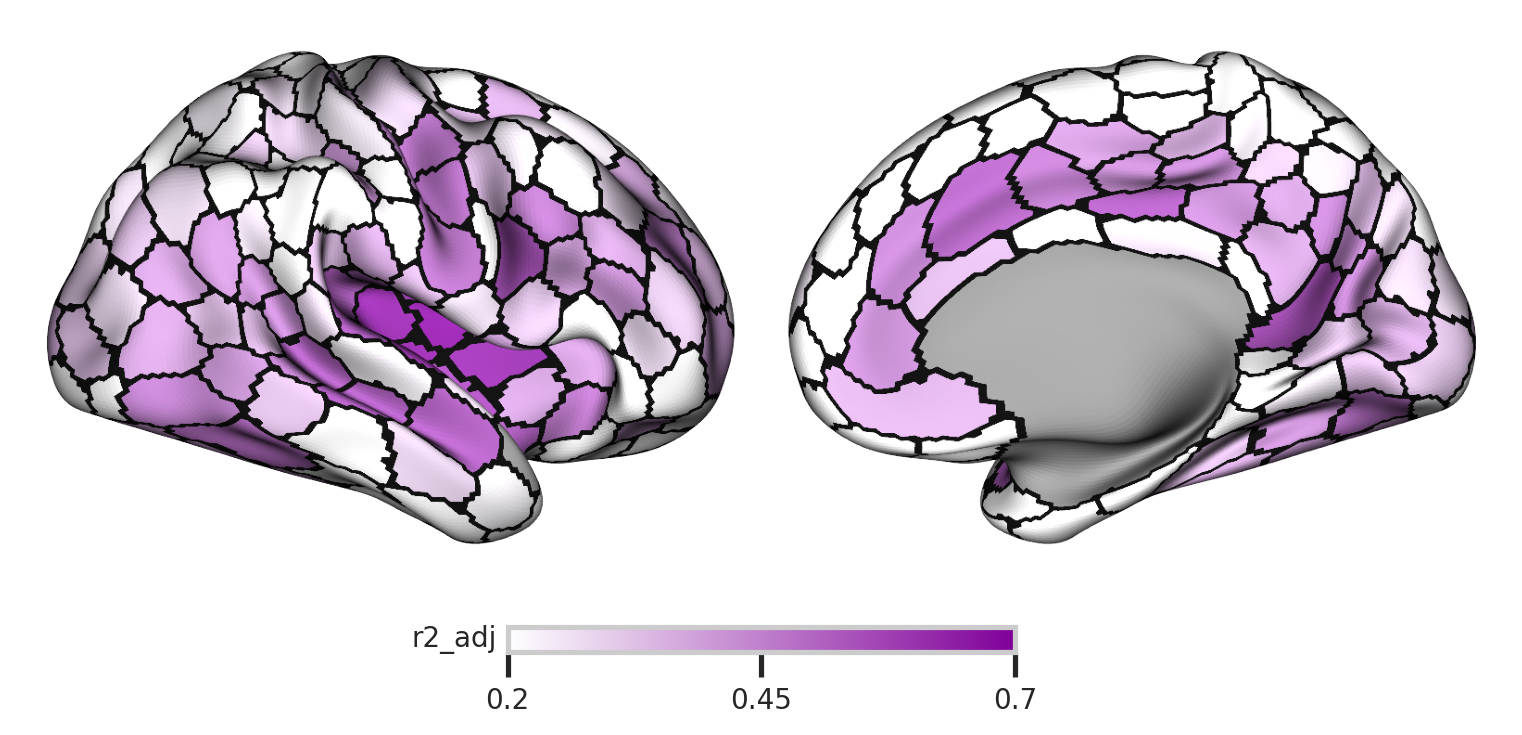

In [58]:
vmin = 1 if "(f)" in value_column else 0.2
vmax = 7 if "(f)" in value_column else 0.7
# vmin = -vis_df[value_column].abs().quantile(0.5)
# vmax = vis_df[value_column].abs().quantile(0.5)
# vmax = 7

cmap = "Reds" if "(f)" in value_column else CMAP_WEIGHTED

# Corrected loop for plotting each hemisphere independently
for hemi_key, hemi_surf_data, mapped_data, parcellation_data in zip(
    ["left", "right"],  # The key for surfplot's dictionary
    [lh, rh],  # The surface object for the current hemisphere
    [data_lh_mapped, data_rh_mapped],  # The mapped data for the current hemisphere
    [lh_parc, rh_parc],  # The parcellation for the current hemisphere
):
    # ---------------------------------------------------------------------
    # 5.  BUILD THE PLOT
    # ---------------------------------------------------------------------
    pref_surf = {
        "surf_lh": hemi_surf_data if hemi_key == "left" else None,
        "surf_rh": hemi_surf_data if hemi_key == "right" else None,
    }

    views = ["lateral", "medial"] if hemi_key == "right" else ["medial", "lateral"]
    p = Plot(
        **pref_surf,  # Unpack the surface dictionary
        views=views,  # Show both medial and lateral for this hemi
        size=(800, 300),  # px; change as needed
        zoom=1.6,
        layout="row",  # For a single hemisphere, row is fine
        mirror_views=False,  # Set to False, as we are plotting one hemi at a time
    )

    # ---- main data layer -------------------------------------------------
    # Pass only the data for the current hemisphere
    # The dictionary now contains only one key-value pair for the current hemisphere
    p.add_layer(
        {hemi_key: mapped_data},
        # cmap="Purples",
        cmap=cmap,
        # cmap="coolwarm",
        color_range=(vmin, vmax),  # Use symmetric range
        # norm=norm,  # Apply the symmetric normalization
        cbar_label=value_column,
        cbar=True,  # Ensure colorbar is shown for each plot if desired, or handle globally
    )
    # ---- outline layer ---------------------------------------------------
    p.add_layer({hemi_key: parcellation_data}, cmap="gray", as_outline=True, cbar=False)

    fig = p.build(
        # cbar_kws=dict(location="bottom", decimals=2, shrink=0.6)
    )  # Added cbar_kws for better cbar display
    # save figure
    savefig_nice(
        fig, OUTPUT_DIR.resolve() / f"fig2_{metric}_{hemi_key}_{value_column}.png", dpi=400
    )

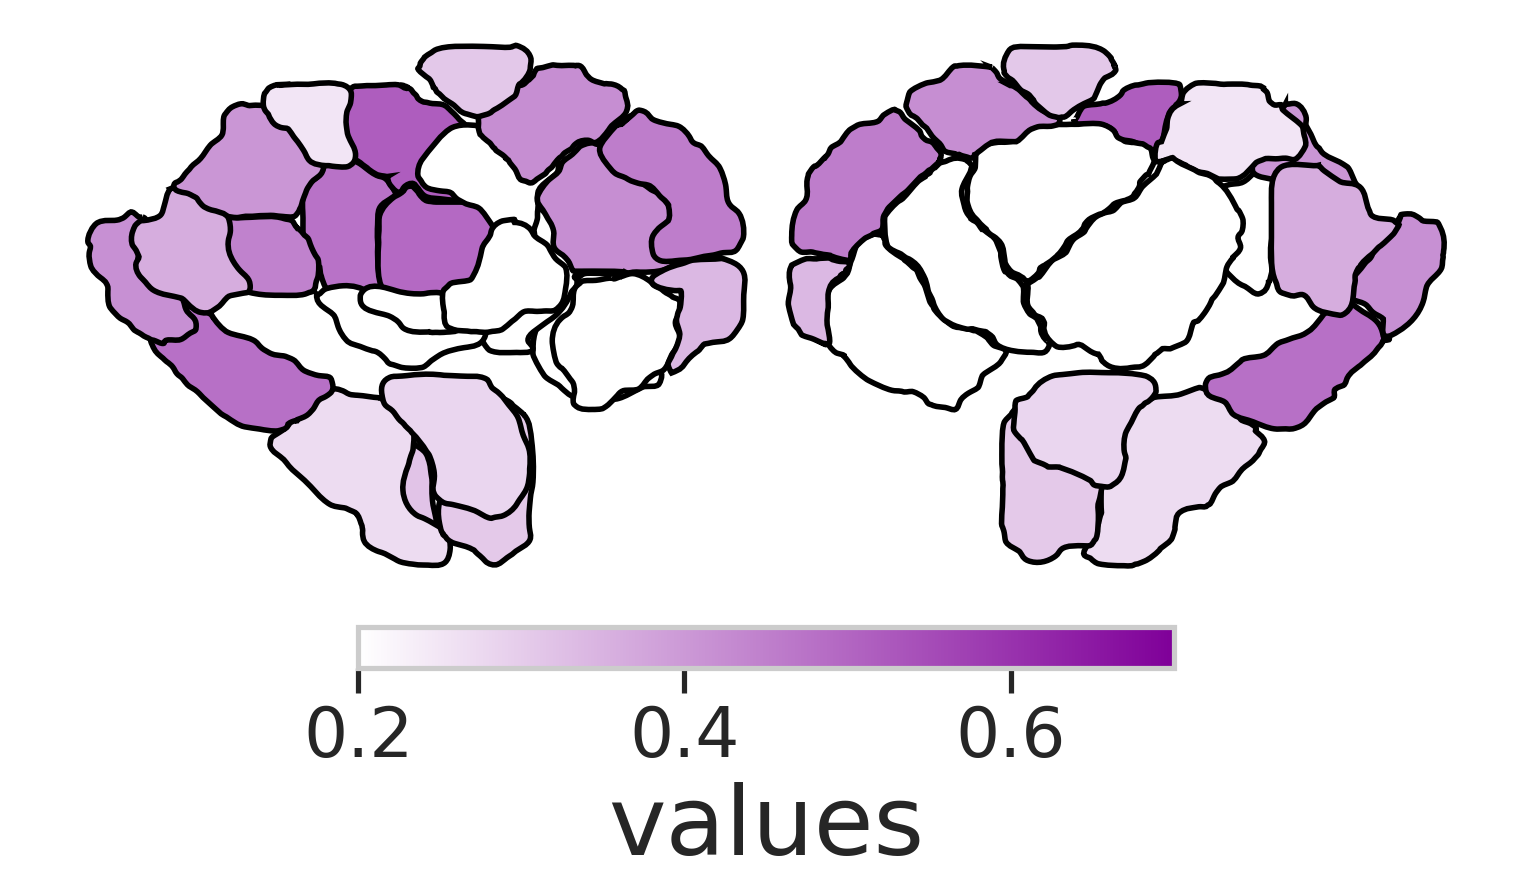

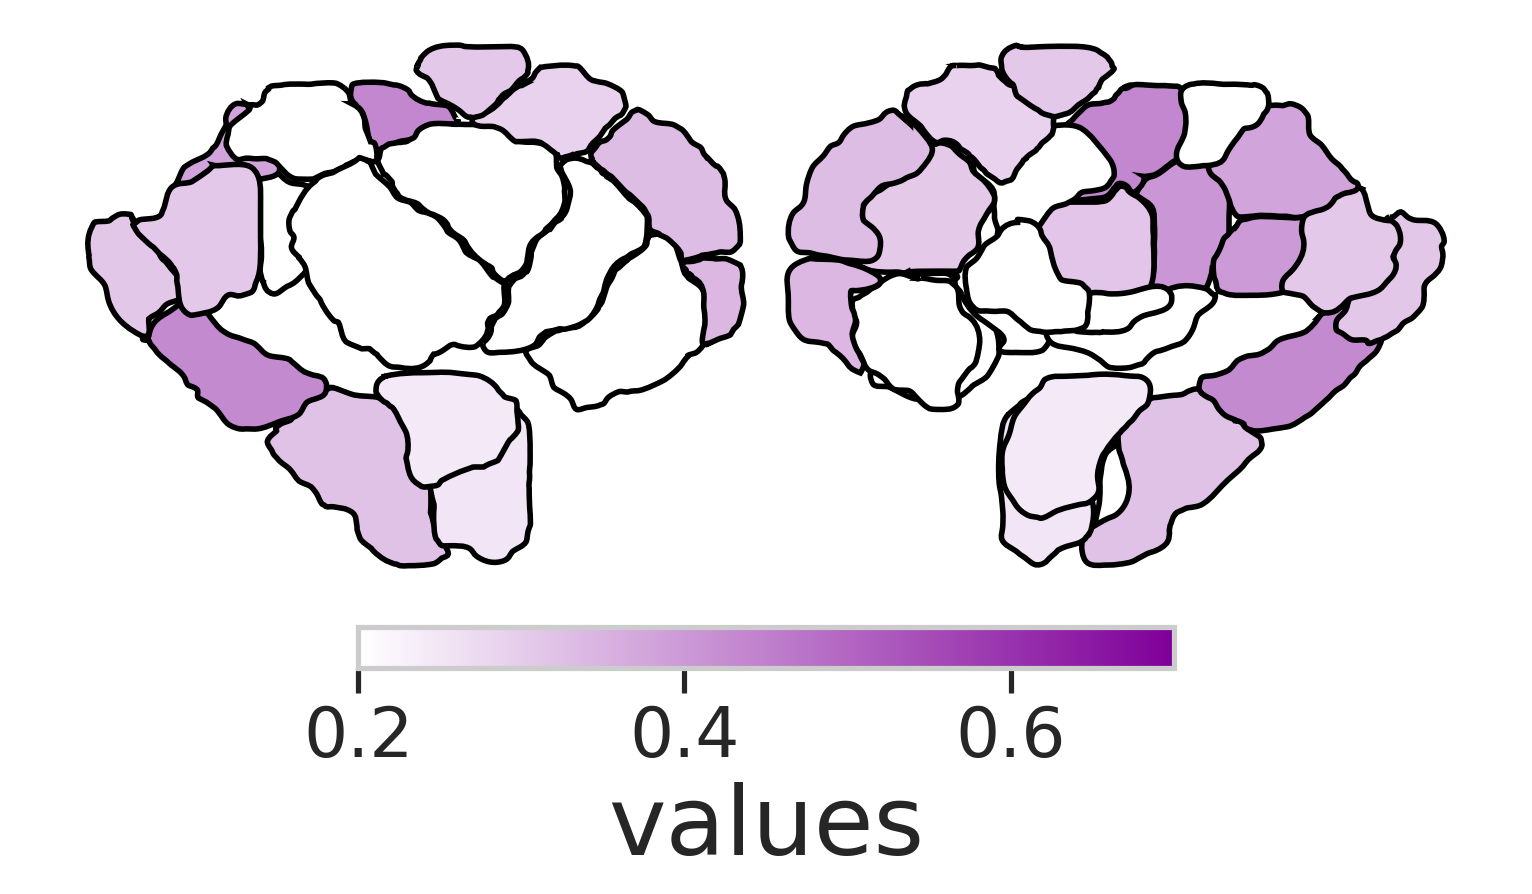

In [59]:
from subcortex_visualization.plotting import plot_subcortical_data

subcort_df = pd.DataFrame(value_map_subcortex)
if "schaefer" in ATLAS:
    subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])


for hemi in ["L", "R"]:

    fig = plot_subcortical_data(
        subcort_df,
        atlas="Melbourne_S3",
        show_legend=True,
        hemisphere=hemi,
        # cmap="coolwarm",
        cmap=cmap,
        line_color="black",
        line_thickness=2,
        vmin=vmin,
        vmax=vmax,
        show_figure=False,
    )

    # save figure
    savefig_nice(fig, OUTPUT_DIR / f"fig2_subcort_{metric}_{hemi}_{value_column}.png", dpi=400)

In [53]:
example_rois = {
    413: {"name": "R. Putamen", "component": "Basal Ganglia"},
    447: {"name": "L. Amygdala", "component": "Limbic System"},
    168: {"name": "L. PFC", "component": "Prefrontal Cortex"},
    179: {"name": "L. PFC", "component": "Prefrontal Cortex"},
    50: {"name": "L. Postcentral", "component": "Somatomotor"},
    258: {"name": "R. Precentral", "component": "Somatomotor"},
    405: {"name": "R. Hippocampus", "component": "Limbic System"},
    234: {"name": "Insula", "component": "Insular Cortex"},
    263: {"name": "L. Precentral", "component": "Somatomotor"},
    312: {"name": "Precuneus", "component": "Parietal Cortex"},
    267: {"name": "R. Precentral", "component": "Somatomotor"},
    67: {"name": "L. Precentral", "component": "Somatomotor"},
}

In [55]:
w_compare.sort_values("p_corrected").head(10)
# w_compare.loc[263]

,index,name,base_name,Label Name,network,component,hemisphere,f,pvalue,n,AIC(lin),AIC(quad),delta_AIC,log(f),p_corrected
234,235,7Networks_RH_SomMot_5,7networks_rh_sommot,7Networks_RH_SomMot,somatomotor,somatomotor,R,1487.080926,2.807580e-257,2583.0,-39264.999153,-40438.981946,-1173.982793,7.304570,1.274641e-254
157,158,7Networks_LH_Default_Temp_10,7networks_lh_default_temp,7Networks_LH_Default_Temp,default,temporal,L,1400.158070,3.617713e-245,2583.0,-40012.594890,-41130.760703,-1118.165812,7.244340,8.212208e-243
34,35,7Networks_LH_SomMot_4,7networks_lh_sommot,7Networks_LH_SomMot,somatomotor,somatomotor,L,1355.327884,8.094614e-239,2583.0,-39711.772144,-40800.672065,-1088.899921,7.211799,1.224985e-236
140,141,7Networks_LH_Cont_PFCl_7,7networks_lh_cont_pfcl,7Networks_LH_Cont_PFCl,control,lateral prefrontal cortex,L,1210.982973,7.199871e-218,2583.0,-39215.764407,-40208.115569,-992.351162,7.099188,8.171853e-216
235,236,7Networks_RH_SomMot_6,7networks_rh_sommot,7Networks_RH_SomMot,somatomotor,somatomotor,R,1198.964654,4.340031e-216,2583.0,-39458.701116,-40442.848378,-984.147262,7.089214,3.940749e-214
99,100,7Networks_LH_SalVentAttn_FrOperIns_4,7networks_lh_salventattn_froperins,7Networks_LH_SalVentAttn_FrOperIns,salience / ventral attention,frontal operculum insula,L,1167.944169,1.814083e-211,2583.0,-37939.730676,-38902.581635,-962.850959,7.063000,1.372656e-209
304,305,7Networks_RH_SalVentAttn_FrOperIns_4,7networks_rh_salventattn_froperins,7Networks_RH_SalVentAttn_FrOperIns,salience / ventral attention,frontal operculum insula,R,1155.372893,1.387874e-209,2583.0,-39129.640937,-40083.811169,-954.170232,7.052178,9.001356e-208
370,371,7Networks_RH_Default_Temp_5,7networks_rh_default_temp,7Networks_RH_Default_Temp,default,temporal,R,1136.150106,1.084036e-206,2583.0,-39615.288159,-40556.127990,-940.839830,7.035401,6.151904e-205
154,155,7Networks_LH_Default_Temp_7,7networks_lh_default_temp,7Networks_LH_Default_Temp,default,temporal,L,1120.633526,2.404293e-204,2583.0,-41498.099826,-42428.128988,-930.029161,7.021649,1.212832e-202
33,34,7Networks_LH_SomMot_3,7networks_lh_sommot,7Networks_LH_SomMot,somatomotor,somatomotor,L,1107.732782,2.182574e-202,2583.0,-38311.396980,-39232.403395,-921.006415,7.010071,9.908886e-201


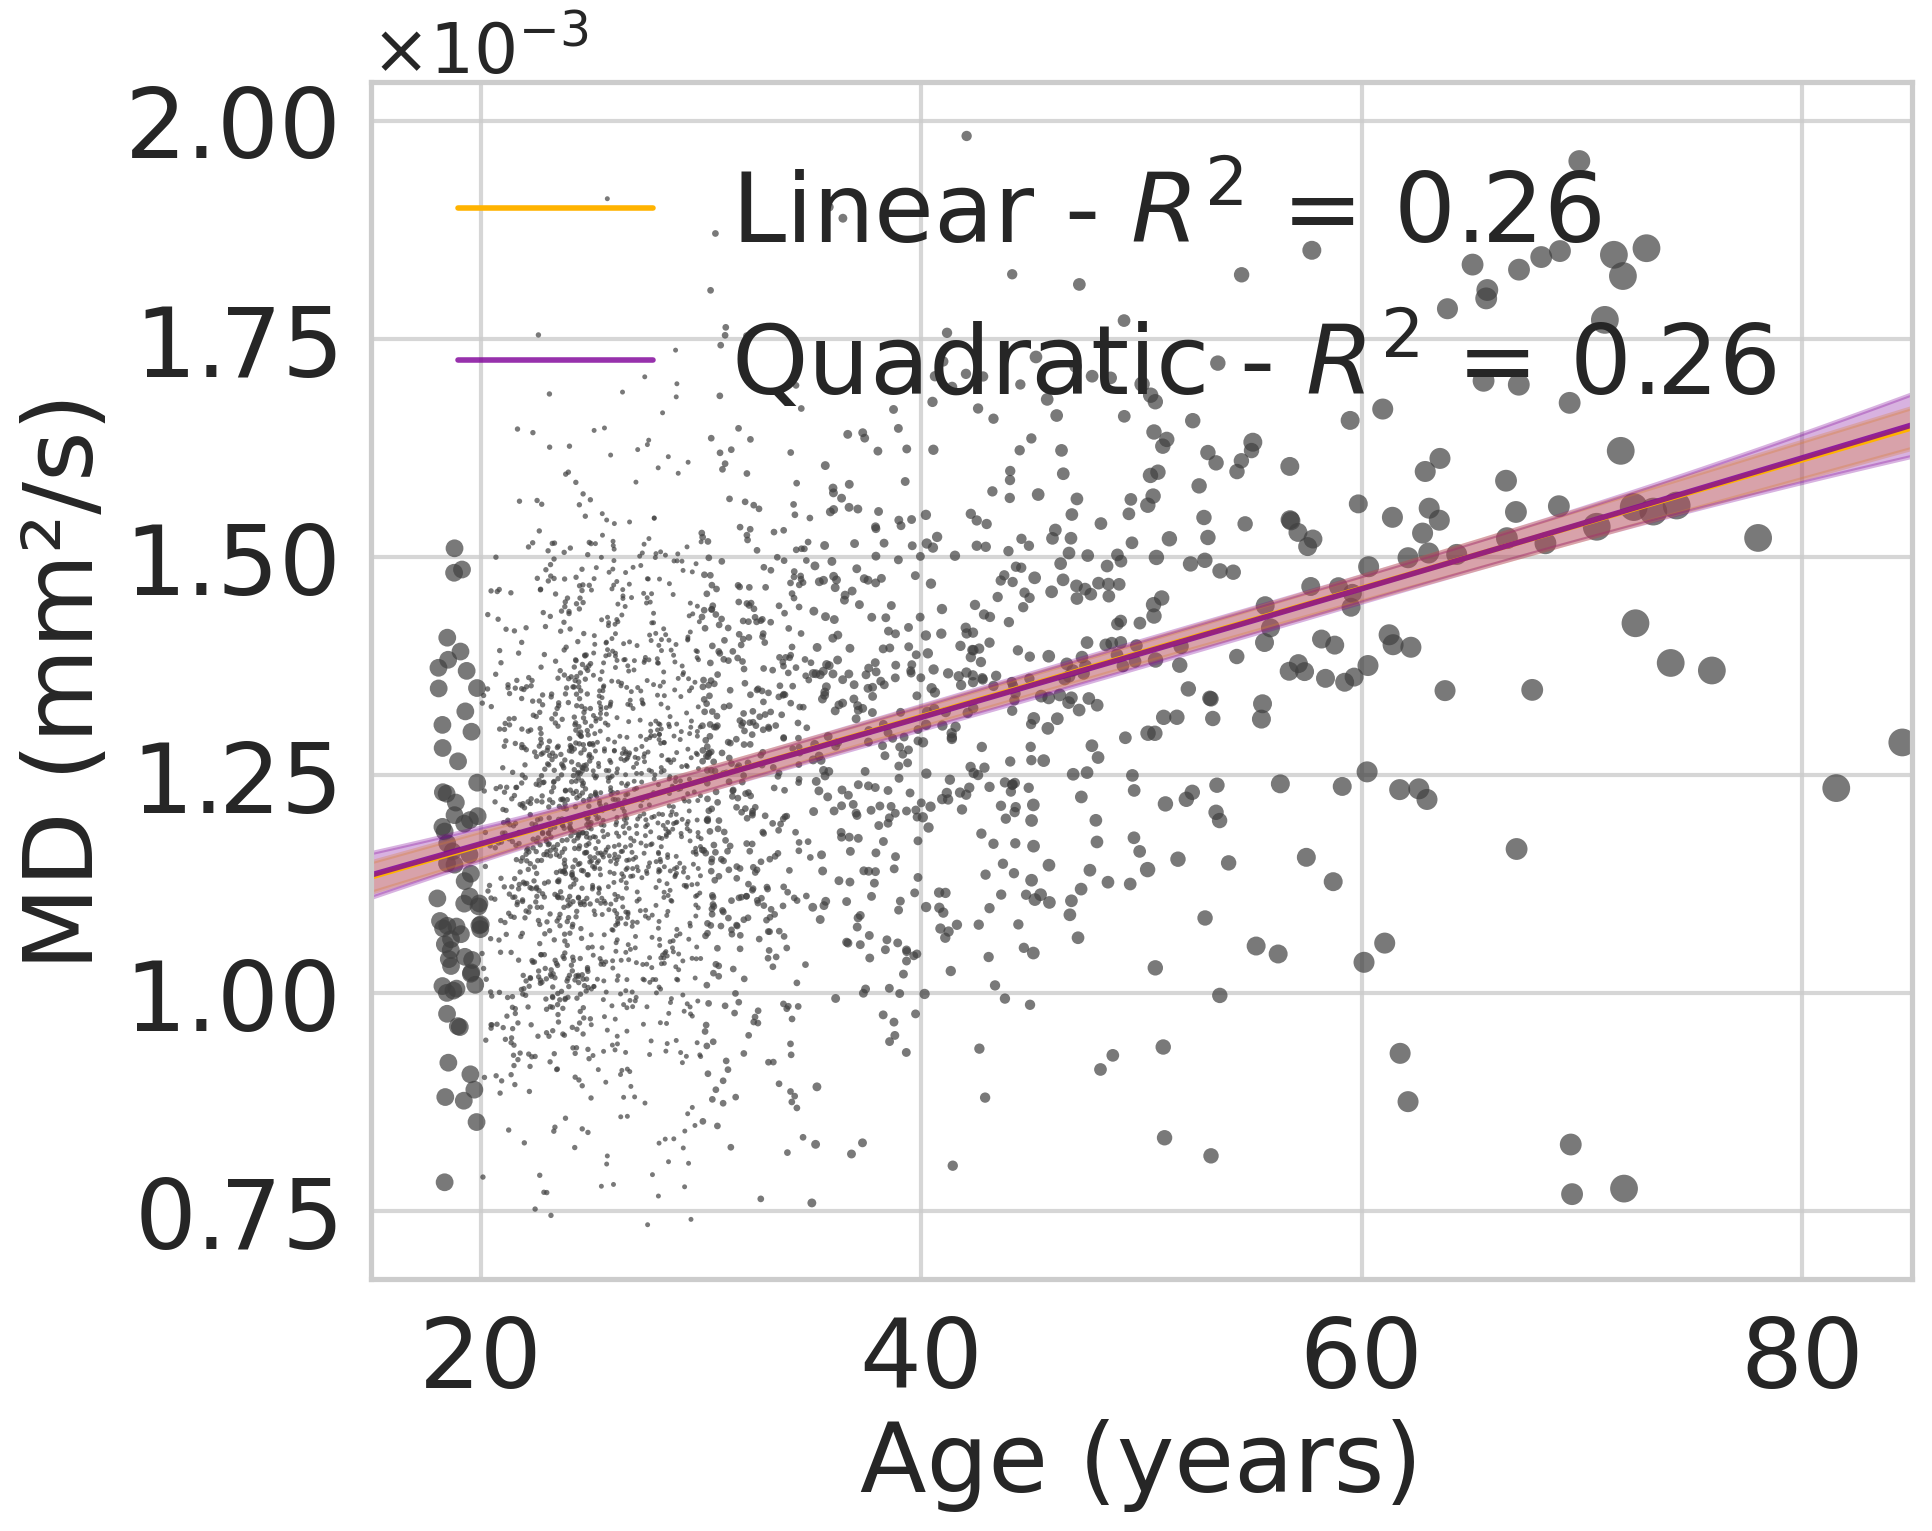

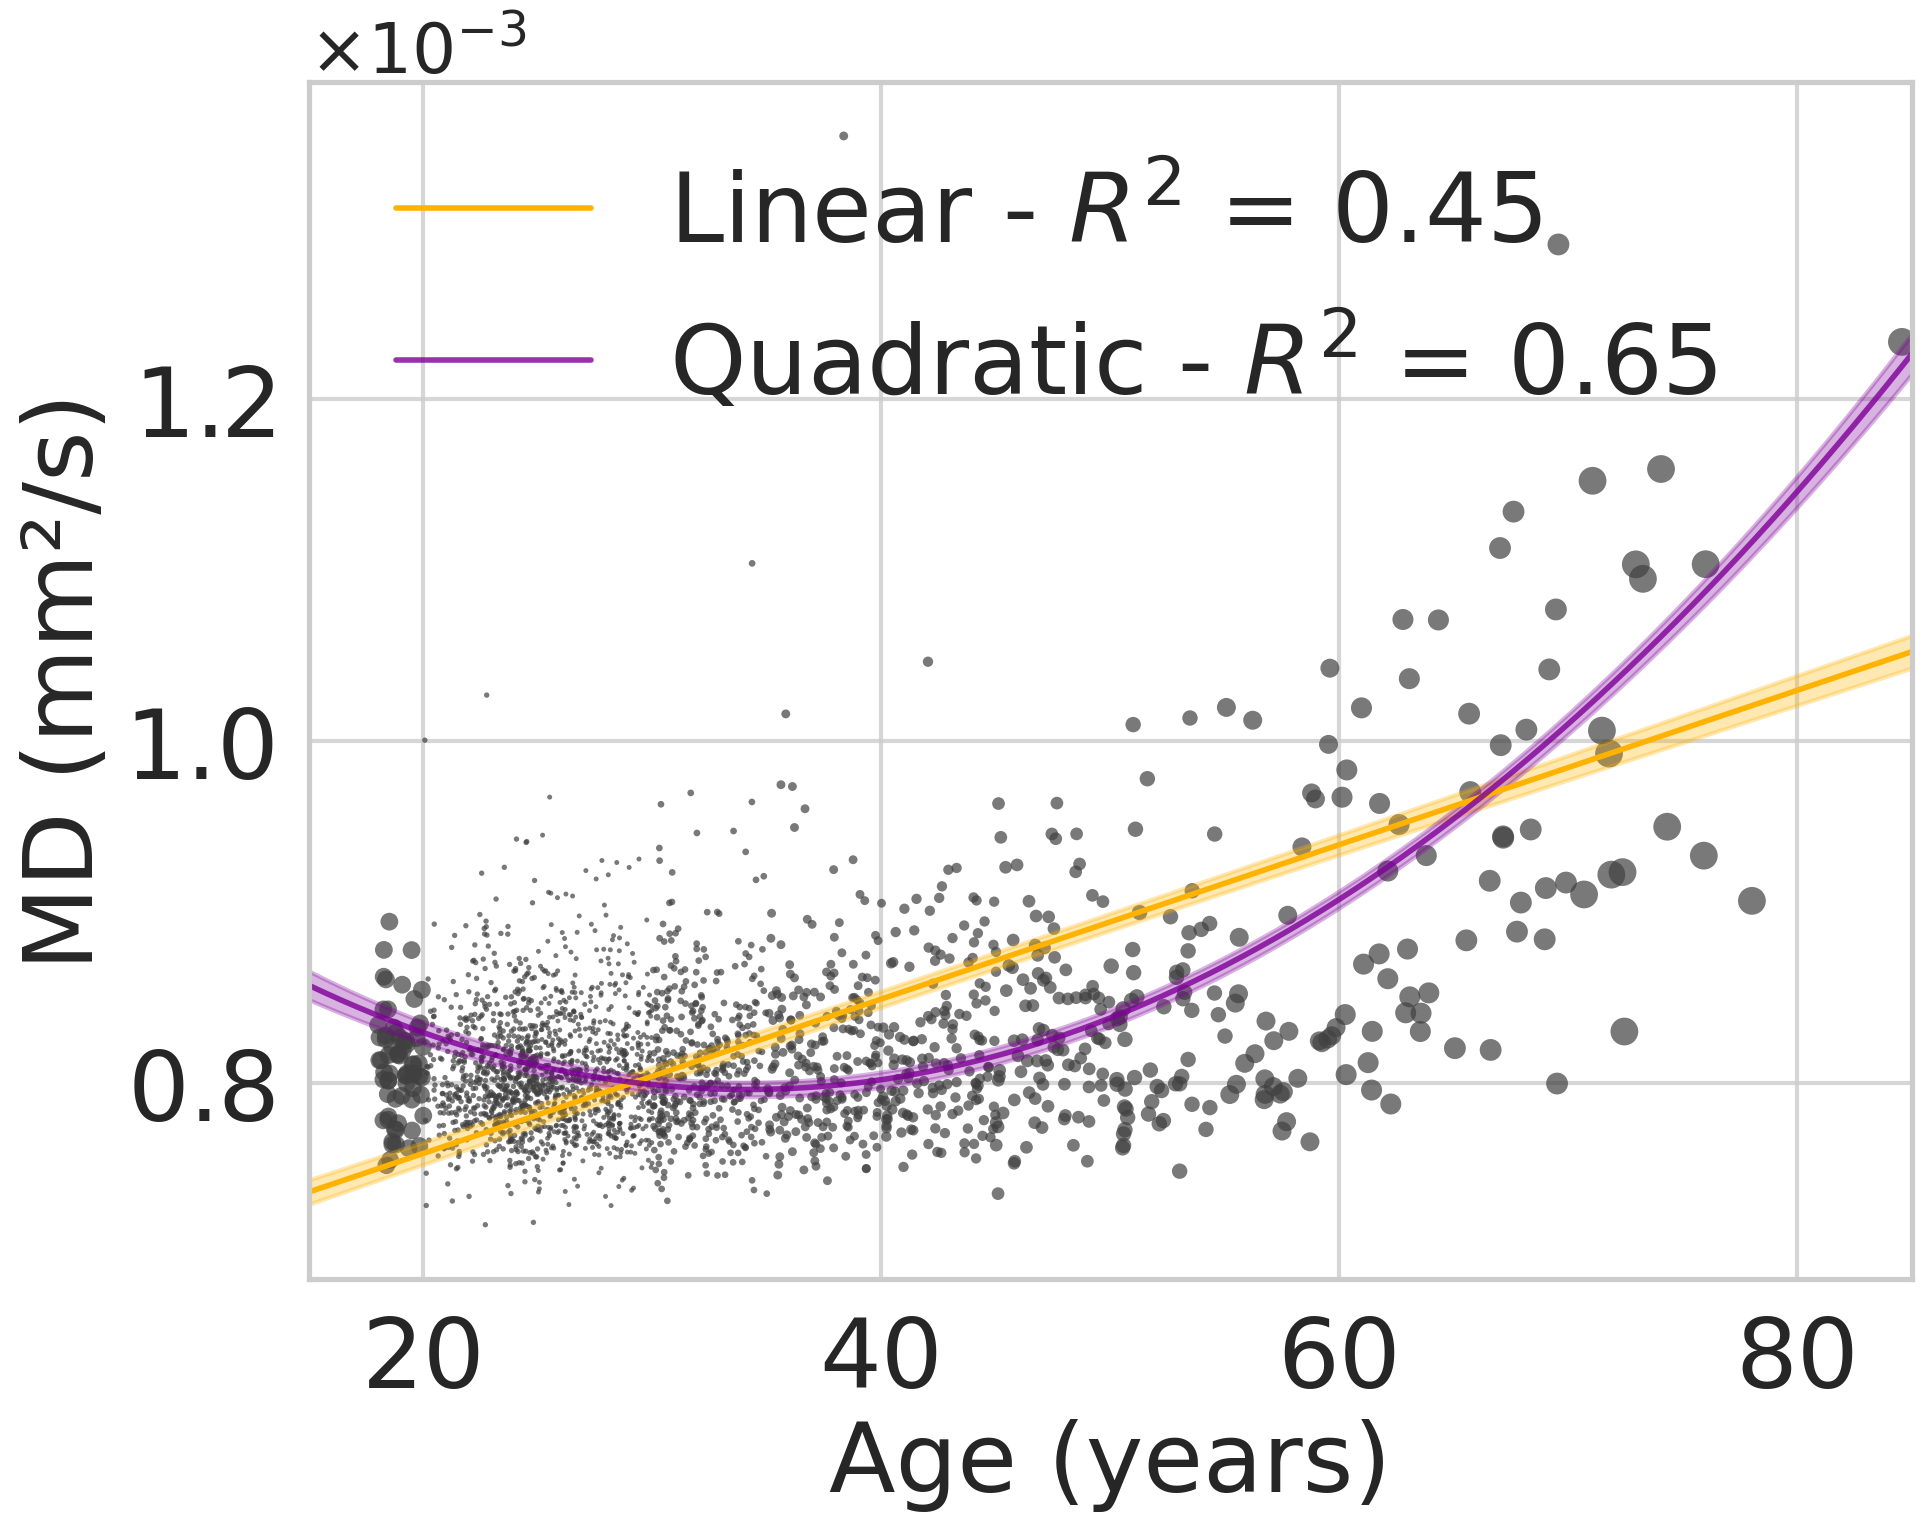

In [56]:
age_min, age_max = 15, 85
age_col = "age_at_scan"

rois = [67, 405] if metric == "gm_vol" else [263, 234]

for i in rois:
    lm = lin_w.loc[i, "model"]
    qm = quad_w.loc[i, "model"]

    d = data[data[region_col] == parcels.loc[i, region_col]].copy()
    # remove outliers
    d = d[
        (d[metric_col] > d[metric_col].quantile(0.001))
        & (d[metric_col] < d[metric_col].quantile(0.999))
    ]
    # d = d[(d[metric_col] > d[metric_col].quantile(0.001))]

    # ────────────────── Panel B: Predicted trajectory ± 95 % CI ──────────────

    mpl.rcParams.update({"axes.labelsize": 35, "ytick.labelsize": 25, "xtick.labelsize": 25})

    fig, ax = plt.subplots(figsize=(10, 8))

    # 3. Prediction frame

    # ── 3. Prediction grid ──────────────────────────────────────────────
    age_grid = np.linspace(age_min, age_max, 300)
    grid_df = pd.DataFrame({age_col: age_grid, "age_squared": age_grid**2})

    # add any covariates present in models (use median/mode)
    covs = [v for v in qm.model.exog_names if v not in ["Intercept", age_col, "age_squared", "I(age_at_scan ** 2)"]]
    for c in covs:
        if pd.api.types.is_numeric_dtype(data[c]):
            grid_df[c] = d[c].median()
        else:
            grid_df[c] = d[c].mode()[0]

    # 4. Get predictions & CI
    for tag, model in [("Linear", lm), ("Quadratic", qm)]:
        pr = model.get_prediction(grid_df)
        ci = pr.conf_int(alpha=0.05)
        grid_df[f"{tag}_fit"] = pr.predicted_mean
        grid_df[f"{tag}_lo"] = ci[:, 0]
        grid_df[f"{tag}_hi"] = ci[:, 1]

    # 5. Plot
    ax.clear()  # reuse the same axes handle

    # Background scatter (down-sample for speed / clarity)
    sizes = np.clip(d["weight"] * 10, 0, 100)
    sns.scatterplot(
        data=d,
        x=age_col,
        y=metric_col,
        alpha=0.7,
        s=sizes,
        edgecolor="none",
        ax=ax,
        legend=False,
        color=COL_REF,
    )

    # # Fit lines & ribbons
    for tag, color, model in zip(["Linear", "Quadratic"], [COL_RAW, COL_WEIGHTED], [lm, qm]):
        # label = f"{tag} - $R^2$ = {model.rsquared:.2f}, AIC = {int(np.round(model.aic)):d}"
        label = f"{tag} - $R^2$ = {model.rsquared:.2f}"
        ax.plot(age_grid, grid_df[f"{tag}_fit"], label=label, lw=2, color=color)
        ax.fill_between(
            age_grid,
            grid_df[f"{tag}_lo"],
            grid_df[f"{tag}_hi"],
            color=color,
            alpha=0.3,
        )

    # add age star
    # stab_age = stab_df.loc[i, "age_star"]

    # if stab_age > 18:
    #     lab = f"Peak Structural Integrity (APSI) = {stab_age:.1f} years"
    # else:
    #     lab = f"Peak Structural Integrity (APSI) ≤ {stab_age:.1f} years"

    # ax.axvline(
    #     stab_age,
    #     color="green",
    #     linestyle="--",
    #     lw=3,
    #     label=lab,
    # )

    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)
    if metric == "gm_vol":
        ylabel = "GM Volume (mm³)"
        # set y axis format to cm instead of mm
    else:
        ylabel = "MD (mm²/s)"

    ax.set(
        xlabel="Age (years)",
        ylabel=ylabel,
        xlim=(age_min, age_max),
    )

    # change tick size
    ax.tick_params(axis="both", which="major", labelsize=35)
    # title = "(A) GM Volume" if metric == "gm_vol" else "(B) Mean Diffusivity"
    # suptitle = example_rois.get(i, {}).get("name", f"Region {i}")

    # ax.set_title("Predicted trajectory (± 95 % CI)")
    # ax.set_title(title, fontsize=30, pad=20)
    ax.legend(frameon=False, fontsize=35, loc="upper left")

    # model_type = "quad" if use_quadratic else "linear"
    savefig_nice(
        fig,
        OUTPUT_DIR / f"fig2_{metric}_{i+1}.png",
        tight=True,
        dpi=300,
    )